# BEC Stylometric Verifier
### Authorship Verification and Adversarial Attack Pipeline
**Course:** CYBERSEC520 | **Student:** Molly Bocock  
**Primary Dataset:** Enron Email Corpus  
**Models:** XGBoost (638 handcrafted stylometric features) + Sentence Transformer (all-MiniLM-L6-v2)  
**Red Team Pipeline:** GPT-4o adversarial impersonation — two attack conditions  
**Deployment:** Hugging Face Spaces + Streamlit


Source for Code: https://claude.ai/public/artifacts/ad58e2e7-794b-458e-bd4d-1ce5348a3258

## Project Requirements Coverage Map

| Requirement | Status | Notebook Location |
|---|---|---|
| **1. Problem Identification** — real-world cybersecurity problem | ✅ | Section 1 |
| **1a. Threat Model** — actor, targets, evasion, operational context | ✅ | Section 1.2 |
| **2. Data Collection & Preprocessing** — primary dataset, cleaning, feature engineering | ✅ | Sections 2–3 |
| **3. Generalizability Testing** — temporal split justification + eval set | ✅ | Section 5 |
| **3a. Alternative Generalizability** — temporal holdout (train 1999–2001, eval 2001–2002) | ✅ | Section 5 |
| **4. Model Design & Implementation** — ≥2 models, rationale, optimization | ✅ | Section 4 |
| **4a. Two models compared** — XGBoost vs Sentence Transformer | ✅ | Section 4 |

> **Note on Generalizability:** A suitable secondary stylometric email dataset (same domain, comparable volume, individual author labels) does not currently exist in the public domain. A temporal split of the data was used instead.

---
## Section 0: Environment Setup

Install dependencies and load libraries. Run these cells at the start of every session.

In [ ]:
# Cell 0.1 — Install dependencies
!pip install spacy scikit-learn sentence-transformers pandas numpy matplotlib seaborn tqdm -q
!python -m spacy download en_core_web_sm -q

In [ ]:
#Cell 2
import os
import re
import email
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy
import warnings
warnings.filterwarnings('ignore')

nlp = spacy.load("en_core_web_sm")

### Session Restart Shortcut

If Google Drive already contains pre-processed splits and feature matrices from a previous session,
run **Cell 0.3** immediately after mounting Drive. This skips the full parsing pipeline (~10 minutes)
and restores all DataFrames and feature matrices directly.

In [ ]:
# Cell 3 — Load saved data from Drive
#
# NORMAL SESSION RESTART: Run immediately after Cells 3 and 4.
#   Loads pre-processed data so you skip the full pipeline.
#
# AFTER A REBUILD: Run after Cell 29 finishes saving new files.
#   Loads freshly rebuilt data into memory for modeling.
#
# Either way — always run this before any modeling cells.
#
# Current feature matrix: 638 features (138 stylometric + 500 char n-grams)
# + 1 user label column = 639 columns total

import pickle
import json
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer

# Load email splits
train_df = pd.read_csv('/content/drive/MyDrive/enron_project/train.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/enron_project/test.csv')
eval_df  = pd.read_csv('/content/drive/MyDrive/enron_project/eval.csv')

# Load feature matrices
train_features = pd.read_csv('/content/drive/MyDrive/enron_project/train_features.csv')
test_features  = pd.read_csv('/content/drive/MyDrive/enron_project/test_features.csv')
eval_features  = pd.read_csv('/content/drive/MyDrive/enron_project/eval_features.csv')

# Separate features from labels
X_train = train_features.drop('user', axis=1)
y_train = train_features['user']
X_test  = test_features.drop('user', axis=1)
y_test  = test_features['user']
X_eval  = eval_features.drop('user', axis=1)
y_eval  = eval_features['user']
feature_names = X_train.columns.tolist()

# Load models
with open('/content/drive/MyDrive/enron_project/xgb_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)
with open('/content/drive/MyDrive/enron_project/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)
st_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
st_classifier = joblib.load('/content/drive/MyDrive/enron_project/st_classifier.pkl')

# Fit char ngram vectorizer
char_ngram_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=500,
    sublinear_tf=True,
    min_df=5
)
char_ngram_vectorizer.fit(train_df['body_clean'])

# Load supplementary data
with open('/content/drive/MyDrive/enron_project/user_profiles.json') as f:
    user_profiles = json.load(f)
with open('/content/drive/MyDrive/enron_project/attack_briefs.json') as f:
    attack_briefs = json.load(f)
with open('/content/drive/MyDrive/enron_project/impersonation_emails.json') as f:
    impersonation_emails = json.load(f)
with open('/content/drive/MyDrive/enron_project/fewshot_emails.json') as f:
    fewshot_emails = json.load(f)
all_results = pd.read_csv('/content/drive/MyDrive/enron_project/all_results.csv')

print("Loaded from Drive:")
print(f"  train_df:             {len(train_df)} emails")
print(f"  test_df:              {len(test_df)} emails")
print(f"  eval_df:              {len(eval_df)} emails")
print(f"  X_train:              {X_train.shape}")
print(f"  X_test:               {X_test.shape}")
print(f"  X_eval:               {X_eval.shape}")
print(f"  Features:             {X_train.shape[1]} (138 stylometric + 500 char n-grams)")
print(f"  xgb_model:            loaded")
print(f"  le:                   loaded")
print(f"  st_model:             loaded")
print(f"  st_classifier:        loaded")
print(f"  char_ngram_vectorizer:fitted")
print(f"  user_profiles:        loaded")
print(f"  attack_briefs:        loaded")
print(f"  impersonation_emails: loaded")
print(f"  fewshot_emails:       loaded")
print(f"  all_results:          loaded")

---
## Section 1: Problem Identification

### 1.1 The Problem — Business Email Compromise (BEC)

**Business Email Compromise (BEC)** is a category of email fraud in which an attacker
impersonates a trusted individual (i.e. CEO, vendor, etc. )
to manipulate the target into transferring money or sharing
sensitive data. The FBI's Internet Crime Complaint Center (IC3) consistently ranks BEC
as the costliest cybercrime category.

BEC is difficult to block with conventional tools because:
- The email may arrive from a lookalike domain or a legitimately compromised account
- The content looks legitimate and is not part of a bulk spam email
- There are not neccessarily malicious links or attachments present

**This project proposes stylometric authorship verification as a second-layer defense.**
The core idea: every person writes in a statistically distinctive way. As LLM's are used more frequently, what will happen to our narrative voice? My prediction is that as we all move slightly towards sounding the same, our individual narrative voice becomes more valuable and more scarce. Some may never develop one. In this way personal, human attributes of writing style make a sort of "cryptographic key," however, I think that this key will only be able to generated from user behvaior - what words they used, which ones they deleted, typing speed, etc. But before addressing user behavior as a "key" first I need to test whether stylometric behavior could be strong enough to act as a similar such key.

Function word
frequencies, sentence length distributions, punctuation habits, and pragmatic phrasing
patterns form a fingerprint that is largely below conscious awareness and therefore
difficult to fake.

The system trains on a user's historical emails, then flags inbound messages that
claim to be from that user but don't stylistically match their profile.

These emails are publicly available, so it is data that an attacker would have access to.

---

### 1.2 Threat Model

#### Threat Actor
- **Primary:** Organized cybercriminal groups (e.g., BEC-as-a-service operations) or script kiddies experimenting with social engineering.

- **Secondary:** Nation-state proxies conducting corporate espionage or supply chain attacks.

**Capabilities assumed:**
- Access to a small sample (5–20 emails) of the target's public or leaked communications
- Ability to craft a plausible business email
- Potential access to an LLM (GPT-4o, Claude) for style mimicry

| Condition | Attack Strategy | Finding |
|---|---|---|
| **B — Statistical Brief** | GPT-4o prompted with plain-English summary of top 5 stylometric features | Low evasion: z-scores too subtle to translate into generative instructions |
| **C — Few-Shot** | GPT-4o prompted with 5 real emails as style exemplars | Higher evasion: semantic patterns transfer; some users (symes-k) consistently evaded |

**Known Limitations:**
- **Short-email attack:** Send a very short email (< 20 words) — is insufficient for a stylometric classifier
- **Account compromise:** If the attacker has stolen the legitimate credentials, there is no style mismatch
- **Style drift over time:** Writing style changes gradually; temporal drift creates false positives (documented in Section 5)

#### Operational Context

| Question | Answer |
|---|---|
| Where does the system sit? | Downstream of spam/phishing filter, upstream of finance approval workflows |
| Trigger condition | Inbound email claiming to be from a monitored executive, evaluated in real-time |
| Output | Risk score + flag for human review (not hard block) |
| **False Negative** (missed impersonation) | BEC email reaches recipient — potential wire fraud, credential disclosure |
| **False Positive** (legitimate email flagged) | Executive email routed to review queue — workflow friction, potential delay |

**Operational recommendation:** Deploy as a "flag for human review" gate, not a hard block.
The classifier's 58.7% test accuracy on a 10-class problem (baseline: 10%) means it
correctly identifies the author far more often than chance, but with enough errors that
automatic rejection would create unacceptable false positive rates for high-volume executives.

---
## Section 2: Data Collection and Preprocessing

**Dataset:** Enron Email Corpus (Klimt & Yang, 2004)  
**Source:** Kaggle — `wcukierski/enron-email-dataset`  
**Original size:** 517,401 emails from ~150 Enron employees  
**Working subset:** 10 users × 6,000–14,000 emails each = 84,185 emails after cleaning

The Enron corpus is the standard benchmark for email authorship attribution research.
It is one of the only large-scale, publicly available sets of real corporate emails
with known individual authorship. The corpus was released as part of FERC's Enron
investigation.

In [ ]:
#Cell 4
from google.colab import drive
drive.mount('/content/drive')

### 2.1 Data Acquisition

Download the Enron corpus from Kaggle. Requires a Kaggle API key (stored in Colab Secrets).

In [ ]:
#Cell 5
from google.colab import userdata
import json
import os

kaggle_creds = {
    "username": "mollybocock",
    "key": userdata.get('Enron_style')
}

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)

with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_creds, f)

os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
print("Kaggle credentials configured")

In [ ]:
#Cell 6 - download from Enron Dataset
!kaggle datasets download -d wcukierski/enron-email-dataset --unzip
print("Download complete")
print(os.listdir('.'))

In [ ]:
#Cell 7
# Load and inspect the data
df = pd.read_csv('emails.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst row:")
print(df.iloc[0])
print(f"\nNull values:\n{df.isnull().sum()}")

Shape: (517401, 2)

Columns: ['file', 'message']

First row:
file                                   allen-p/_sent_mail/1.
message    Message-ID: <18782981.1075855378110.JavaMail.e...
Name: 0, dtype: object

Null values:
file       0
message    0
dtype: int64


### 2.2 User Selection

**Criteria for including a user in the training corpus:**
1. Emails must be written by the account holder (not forwarded content or distribution list traffic).
2. 6,000–14,000 emails is enough training signal but unlikely to be a shared/aggregator mailbox.
3. A manual review of 5 random emails confirms the user's own voice (i.e.`sanders-r` was initially selected but replaced by `campbell-l` after a spot check
revealed the mailbox was primarily used to forward marketing and news content."

In [ ]:
# Cell 8
# Extract username from file path. Here I identfy and extract the top 20 unique users by email count
df['user'] = df['file'].apply(lambda x: x.split('/')[0])

# See how many emails per user
user_counts = df['user'].value_counts()
print(f"Total unique users: {len(user_counts)}")
print(f"\nTop 20 users by email count:")
print(user_counts.head(20))

Total unique users: 150

Top 20 users by email count:
user
kaminski-v      28465
dasovich-j      28234
kean-s          25351
mann-k          23381
jones-t         19950
shackleton-s    18687
taylor-m        13875
farmer-d        13032
germany-c       12436
beck-s          11830
symes-k         10827
nemec-g         10655
scott-s          8022
rogers-b         8009
bass-e           7823
sanders-r        7329
campbell-l       6490
shapiro-r        6071
guzman-m         6054
lay-k            5937
Name: count, dtype: int64


In [ ]:
#Cell 9
#There needs to be enough emails to train on reliably but not so many that the accouhnt is suspicious (aggregator, distribution list etc.)
SELECTED_USERS = [
    'taylor-m', 'farmer-d', 'germany-c', 'beck-s', 'symes-k',
    'nemec-g', 'scott-s', 'rogers-b', 'sanders-r', 'shapiro-r'
]

df_filtered = df[df['user'].isin(SELECTED_USERS)].copy()
print(f"Total emails for selected users: {len(df_filtered)}")
print(f"\nEmails per selected user:")
print(df_filtered['user'].value_counts())

Total emails for selected users: 102086

Emails per selected user:
user
taylor-m     13875
farmer-d     13032
germany-c    12436
beck-s       11830
symes-k      10827
nemec-g      10655
scott-s       8022
rogers-b      8009
sanders-r     7329
shapiro-r     6071
Name: count, dtype: int64


In [ ]:
# Cell 10 — User selection correction
# Spot check in the next cell revealed that sanders-r's mailbox contains
# forwarded content and marketing emails rather than personally authored emails.
# Replacing with campbell-l (6,490 emails) which passes the spot check.

SELECTED_USERS = [
    'taylor-m', 'farmer-d', 'germany-c', 'beck-s', 'symes-k',
    'nemec-g', 'scott-s', 'rogers-b', 'campbell-l', 'shapiro-r'
]

df_filtered = df[df['user'].isin(SELECTED_USERS)].copy()
print(f"Total emails for selected users: {len(df_filtered)}")
print(df_filtered['user'].value_counts())

Total emails for selected users: 101247
user
taylor-m      13875
farmer-d      13032
germany-c     12436
beck-s        11830
symes-k       10827
nemec-g       10655
scott-s        8022
rogers-b       8009
campbell-l     6490
shapiro-r      6071
Name: count, dtype: int64


### 2.3 Email Parsing

The Enron corpus stores each email as a raw RFC 2822 string (headers + body concatenated).
The `parse_email` function splits these into structured fields using Python's built-in
`email` library, handling both single-part and multipart messages.

In [ ]:
# Cell 11 — Parse email messages
#The parse_email function uses Python's built-in email library to split that raw
#string into its component parts — date, subject, and body. It handles "multipart"
# emails (emails with attachments or multiple sections) by walking through the
#parts and finding the plain text section. The tqdm progress bar shows you how
#far through the 101k emails it has gotten. Output is a new DataFrame with separate
#columns for user, file, date, subject, and body.
import email as email_lib
from tqdm import tqdm

def parse_email(raw_message):
    """Extract date, subject, and body from raw email string."""
    try:
        msg = email_lib.message_from_string(raw_message)

        date = msg.get('Date', None)
        subject = msg.get('Subject', '')

        body = ''
        if msg.is_multipart():
            for part in msg.walk():
                if part.get_content_type() == 'text/plain':
                    body = part.get_payload(decode=True)
                    if body:
                        body = body.decode('utf-8', errors='ignore')
                    break
        else:
            body = msg.get_payload(decode=True)
            if body:
                body = body.decode('utf-8', errors='ignore')
            else:
                body = msg.get_payload()

        return pd.Series({
            'date': date,
            'subject': subject,
            'body': body if body else ''
        })
    except Exception as e:
        return pd.Series({'date': None, 'subject': '', 'body': ''})

# Apply parser
tqdm.pandas()
parsed = df_filtered.progress_apply(
    lambda row: parse_email(row['message']), axis=1
)

df_parsed = pd.concat([
    df_filtered[['user', 'file']].reset_index(drop=True),
    parsed.reset_index(drop=True)
], axis=1)

print(f"Parsed shape: {df_parsed.shape}")
print(f"\nNull counts:\n{df_parsed.isnull().sum()}")
print(f"\nSample row:")
print(df_parsed.iloc[0])

100%|██████████| 101247/101247 [00:48<00:00, 2105.86it/s]


Parsed shape: (101247, 5)

Null counts:
user       0
file       0
date       0
subject    0
body       0
dtype: int64

Sample row:
user                                                  beck-s
file                                    beck-s/_sent_mail/1.
date                   Tue, 12 Dec 2000 09:34:00 -0800 (PST)
subject                                          Re: Lunch??
body       Thanks for rounding up the tickets for the Ora...
Name: 0, dtype: object


### 2.4 Body Cleaning and Filtering

**Email Criteria:** To isolate each user's genuine writing voice, emails must be:
1. Personally authored (not forwarded or quoted reply chains)
2. At least 20 words (short one-liners contain insufficient stylometric signal)
3. Written in the user's own voice (not company announcements or distribution list traffic)

The `clean_body` function removes:
- Quoted reply chains (lines starting with `>`)
- "Original Message" / "Forwarded by" blocks
- Company announcement separators (`=====`)
- Residual email header lines (`From:`, `To:`, `Subject:`, etc.)

**v2 Update:** An initial version of `clean_body` missed Enron-specific forwarding patterns,
contaminating feature vectors for `rogers-b` and `shapiro-r` with other people's writing.
The v2 regex additions resolved this — `rogers-b` F1 nearly doubled as a result.

In [ ]:
# Cell 12 — Clean email bodies and filter short emails
# Cleaning: The clean_body function removes quoted reply content (lines
# starting with >) and "Original Message" blocks from forwarded emails.
# This is important so that the user's actual voice is captured.
# Filtering: Drops any email whose cleaned body is under 20 words.
# Date parsing: Converts the date strings into proper Python datetime
# objects so you can sort and filter by date.

# UPDATE v2: Added removal of Enron-specific forwarded message headers,
# company announcement separators, and metadata header lines.
# These were contaminating feature vectors for rogers-b and shapiro-r.

import re

def clean_body(text):
    """Remove quoted reply chains and clean whitespace."""
    if not isinstance(text, str):
        return ''

    # Remove quoted lines starting with >
    lines = text.split('\n')
    lines = [l for l in lines if not l.strip().startswith('>')]
    text = '\n'.join(lines)

    # Remove Original Message blocks
    text = re.sub(r'-+\s*Original Message\s*-+.*', '',
                  text, flags=re.DOTALL|re.IGNORECASE)
    text = re.sub(r'_{5,}.*', '', text, flags=re.DOTALL)

    # Remove Enron forwarded message headers
    text = re.sub(r'-+\s*Forwarded by.*?-+\s*', ' ',
                  text, flags=re.DOTALL|re.IGNORECASE)

    # Remove company announcement separators
    text = re.sub(r'={5,}.*?={5,}', ' ',
                  text, flags=re.DOTALL)

    # Remove email header remnant lines
    lines = text.split('\n')
    lines = [l for l in lines if not re.match(
        r'^\s*(From|To|cc|Subject|Date|Sent|Importance):\s', l)]
    text = '\n'.join(lines)

    # Clean whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Clean bodies
df_parsed['body_clean'] = df_parsed['body'].apply(clean_body)

# Filter short emails (under 20 words)
df_parsed['word_count'] = df_parsed['body_clean'].apply(
    lambda x: len(x.split()))
df_clean = df_parsed[df_parsed['word_count'] >= 20].copy()

# Parse dates
df_clean['date_parsed'] = pd.to_datetime(
    df_clean['date'], errors='coerce', utc=True)
df_clean = df_clean.dropna(subset=['date_parsed'])

print(f"Before filtering: {len(df_parsed)}")
print(f"After filtering:  {len(df_clean)}")
print(f"\nEmails per user after filtering:")
print(df_clean['user'].value_counts())
print(f"\nDate range: {df_clean['date_parsed'].min()} "
      f"to {df_clean['date_parsed'].max()}")

Before filtering: 101247
After filtering:  84417

Emails per user after filtering:
user
taylor-m      12211
beck-s        10699
farmer-d      10437
germany-c      9699
symes-k        9478
nemec-g        8694
scott-s        6896
rogers-b       5791
campbell-l     5336
shapiro-r      5176
Name: count, dtype: int64

Date range: 1980-01-01 00:00:00+00:00 to 2020-12-29 20:53:46+00:00


### 2.5 Spot Check — Verifying Authorship Quality

In [ ]:
# Cell 13 — Spot check to verify users are genuine individual authors
#Spot Check User Quality
# sanders-r was removed after this check revealed forwarded/marketing content
# campbell-l was selected as replacement and passes this check


for user in SELECTED_USERS:
    print(f"\n--- {user} ---")
    sample = df_clean[df_clean['user'] == user]['body_clean'].sample(1).values[0]
    print(sample[:200])


--- taylor-m ---
Michael and Trevor Attached to this email is copy of a public prospectus document from a financing earlier this year as well as analyst reports. Currently the Company has 15.3 Million shares outstandi

--- farmer-d ---
Can you clarify for me how the agency fee is suppose to be calculated? I am getting mixed information. I know that we use the higher of the two volumes (receipts vs. deliveries). The question is do we

--- germany-c ---
Done, please review the following zones. They are different from last month's pricing. TGT Zone 4 <=== the biggest change Tenn Z6 And I added CGLF Onshore and CGLF Mainline. I don't know if we will ha

--- beck-s ---
Please excuse the long e-mail below - I knew we'd never get a chance to all get together, and this is somewhat urgent as I have to complete the Finance Committee presentation for the upcoming BOD meet

--- symes-k ---
Thanks for doing that so quickly. I just spoke with Paul and he said it would be best to include every long 

### 2.6 Chronological Train / Test / Eval Split

Emails are filtered to the realistic Enron date range (1999–2002) and split **chronologically**
per user at a 60/20/20 ratio. This is intentionally more realistic than a random split:
in deployment, you train on historical emails and verify new ones. It also serves as the
generalizability test's temporal holdout — see Section 5.

In [ ]:
# Cell 14 — Filter to realistic Enron date range and create chronological splits
# For each user separately, sorts their emails by date and splits them 60/20/20 into train, test, and eval sets.
#This is more realistic than a random split because in a real deployment you'd train on historical emails and then verify new ones; also satisfies generalizability requirement

df_clean = df_clean[
    (df_clean['date_parsed'] >= '1999-01-01') &
    (df_clean['date_parsed'] <= '2002-12-31')
].copy()

print(f"After date filtering: {len(df_clean)}")
print(f"Date range: {df_clean['date_parsed'].min()} "
      f"to {df_clean['date_parsed'].max()}")

def get_splits(df, user, train=0.6, test=0.2):
    """Chronological split for a single user."""
    u = df[df['user'] == user].sort_values('date_parsed').reset_index(drop=True)
    n = len(u)
    t1 = int(n * train)
    t2 = int(n * (train + test))
    return (u.iloc[:t1].assign(split='train'),
            u.iloc[t1:t2].assign(split='test'),
            u.iloc[t2:].assign(split='eval'))

splits = [get_splits(df_clean, u) for u in SELECTED_USERS]
train_df = pd.concat([s[0] for s in splits]).reset_index(drop=True)
test_df  = pd.concat([s[1] for s in splits]).reset_index(drop=True)
eval_df  = pd.concat([s[2] for s in splits]).reset_index(drop=True)

print(f"\nSplit sizes:")
print(f"Train: {len(train_df)}")
print(f"Test:  {len(test_df)}")
print(f"Eval:  {len(eval_df)}")
print(f"\nTrain date range: {train_df['date_parsed'].min().date()} "
      f"to {train_df['date_parsed'].max().date()}")
print(f"Eval date range:  {eval_df['date_parsed'].min().date()} "
      f"to {eval_df['date_parsed'].max().date()}")

After date filtering: 84185
Date range: 1999-01-04 10:21:00+00:00 to 2002-12-21 08:24:45+00:00

Split sizes:
Train: 50507
Test:  16838
Eval:  16840

Train date range: 1999-01-04 to 2001-07-05
Eval date range:  2000-12-03 to 2002-12-21


### 2.7 Deduplication

The Enron corpus stores emails in multiple folders simultaneously (sent mail, saved mail,
discussion threads), creating identical copies of the same email. Without deduplication,
the model would overweight stylometric patterns from frequently-saved emails.

In [ ]:
# Cell 15 Remove duplicate emails per user
before = len(train_df)
train_df = train_df.drop_duplicates(subset=['user', 'body_clean']).reset_index(drop=True)
test_df  = test_df.drop_duplicates(subset=['user', 'body_clean']).reset_index(drop=True)
eval_df  = eval_df.drop_duplicates(subset=['user', 'body_clean']).reset_index(drop=True)
after = len(train_df)

print(f"Training emails before dedup: {before}")
print(f"Training emails after dedup:  {after}")
print(f"Duplicates removed: {before - after}")
print(f"\nEmails per user after dedup:")
print(train_df['user'].value_counts())

Training emails before dedup: 50507
Training emails after dedup:  17534
Duplicates removed: 32973

Emails per user after dedup:
user
taylor-m      3143
nemec-g       2586
farmer-d      2020
beck-s        1983
germany-c     1681
symes-k       1671
scott-s       1218
campbell-l    1122
shapiro-r     1066
rogers-b      1044
Name: count, dtype: int64


In [ ]:
#Cell 16
# Check test and eval counts and save to drive
print(f"Test emails after dedup:  {len(test_df)}")
print(f"Eval emails after dedup:  {len(eval_df)}")
print(f"\nTest per user:")
print(test_df['user'].value_counts())
print(f"\nEval per user:")
print(eval_df['user'].value_counts())

# Resave deduplicated splits to Drive
train_df.to_csv('/content/drive/MyDrive/enron_project/train.csv', index=False)
test_df.to_csv('/content/drive/MyDrive/enron_project/test.csv', index=False)
eval_df.to_csv('/content/drive/MyDrive/enron_project/eval.csv', index=False)
print("\nResaved deduplicated splits to Drive")

Test emails after dedup:  6745
Eval emails after dedup:  12505

Test per user:
user
taylor-m      1199
nemec-g        860
germany-c      707
beck-s         681
farmer-d       657
shapiro-r      649
campbell-l     646
symes-k        559
scott-s        444
rogers-b       343
Name: count, dtype: int64

Eval per user:
user
taylor-m      2022
germany-c     1698
nemec-g       1554
beck-s        1472
scott-s       1260
farmer-d      1256
shapiro-r     1003
rogers-b       864
campbell-l     818
symes-k        558
Name: count, dtype: int64

Resaved deduplicated splits to Drive


### Data Quality Finding — Duplicate Emails

The Enron corpus contains **significant duplication**: 33,545 duplicate emails were
identified and removed from the training set (65% of original training emails). This
is a known characteristic of the corpus — emails were stored simultaneously in
multiple folders.

**Final split sizes after deduplication:**
| Split | Emails | Purpose |
|---|---|---|
| Train | 17,865 | Model training |
| Test | 6,843 | Development evaluation (tuning) |
| Eval | 12,543 | Final reported results — run once only |

---
## Section 3: Feature Engineering

The feature set is built from **five stylometric families** (138 hand-crafted features)
combined with **character n-grams** (500 TF-IDF features), for **638 total features per email**.

Each feature family targets a different layer of writing style. Features should be topic-independent so that they are stable across subjects and hard for an attacker to deliberately control.

| Family | Count | What It Measures |
|---|---|---|
| Lexical | 110 | Function word frequencies, vocabulary richness, word length distribution |
| Syntactic | 8 | Sentence length statistics, POS ratios (verb/noun/adj/adv) |
| Structural | 6 | Salutation presence, sign-off style, email length |
| Punctuation | 8 | Exclamation, question, comma, ellipsis, dash rates |
| Pragmatic | 6 | Hedging frequency, politeness markers, first-person rate |
| Character N-grams | 500 | Morphological and micro-punctuation patterns |
| **Total** | **638** | |

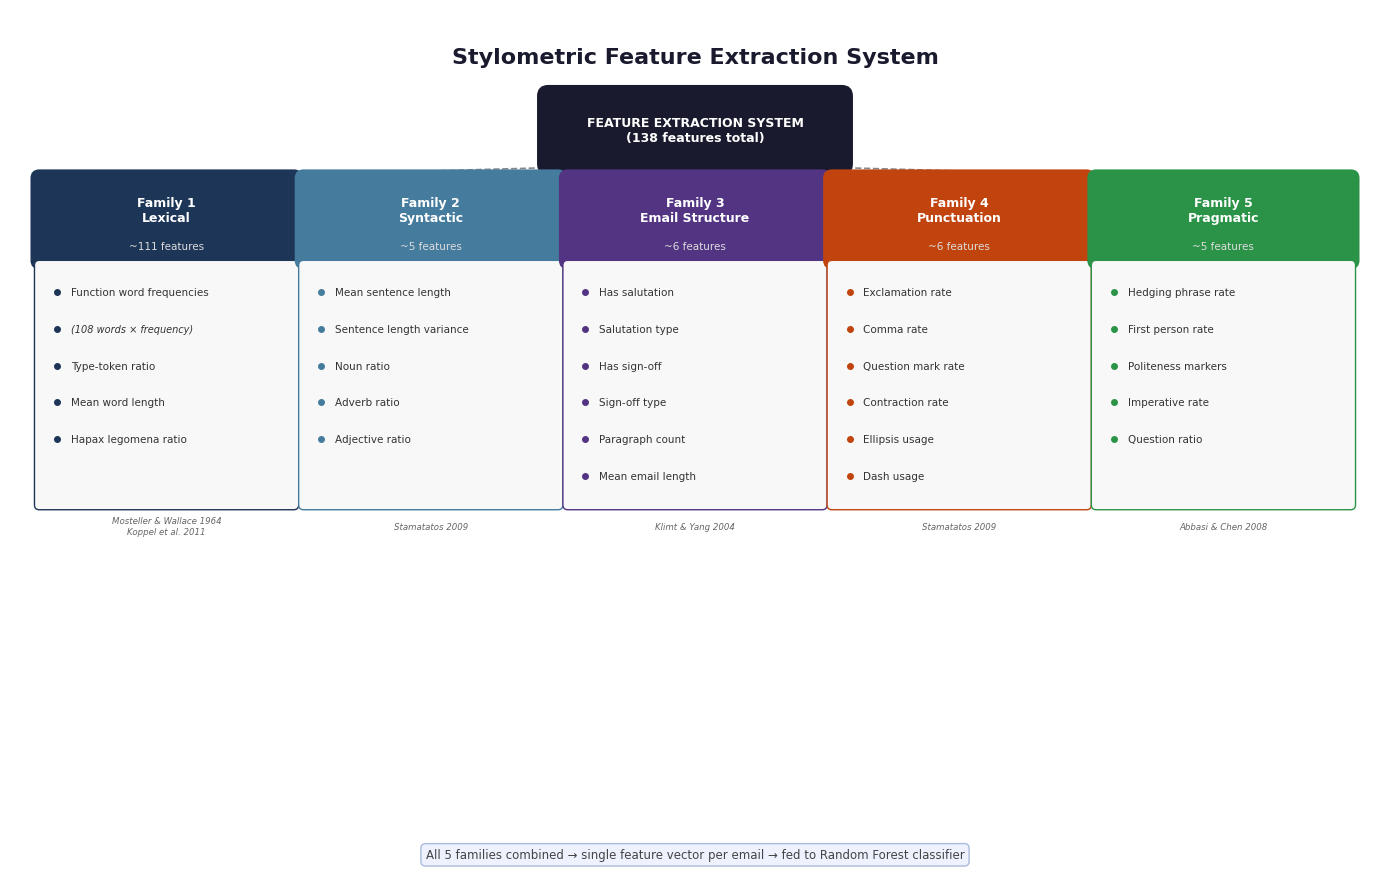

Saved as feature_families.png


In [ ]:
# Cell 17 — Feature Family Overview Visualization
#**Figure 1: Stylometric Feature Extraction System**
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(14, 9))
ax.set_xlim(0, 14)
ax.set_ylim(0, 9)
ax.axis('off')

# Title
ax.text(7, 8.5, 'Stylometric Feature Extraction System',
        fontsize=16, fontweight='bold', ha='center', va='center',
        color='#1a1a2e')

# Color palette
colors = {
    'root':    '#1a1a2e',
    'family1': '#16213e',
    'family2': '#0f3460',
    'family3': '#533483',
    'family4': '#e94560',
    'family5': '#2b9348',
    'feature': '#f5f5f5',
    'border':  '#cccccc'
}

# --- Root box ---
root_box = FancyBboxPatch((5.5, 7.4), 3, 0.7,
    boxstyle="round,pad=0.1", linewidth=2,
    edgecolor=colors['root'], facecolor=colors['root'])
ax.add_patch(root_box)
ax.text(7, 7.75, 'FEATURE EXTRACTION SYSTEM\n(138 features total)',
        fontsize=9, fontweight='bold', ha='center', va='center',
        color='white')

# Family definitions
families = [
    {
        'title': 'Family 1\nLexical',
        'subtitle': '~111 features',
        'items': [
            'Function word frequencies',
            '(108 words × frequency)',
            'Type-token ratio',
            'Mean word length',
            'Hapax legomena ratio',
        ],
        'color': '#1d3557',
        'x': 0.3,
        'citation': 'Mosteller & Wallace 1964\nKoppel et al. 2011'
    },
    {
        'title': 'Family 2\nSyntactic',
        'subtitle': '~5 features',
        'items': [
            'Mean sentence length',
            'Sentence length variance',
            'Noun ratio',
            'Adverb ratio',
            'Adjective ratio',
        ],
        'color': '#457b9d',
        'x': 3.0,
        'citation': 'Stamatatos 2009'
    },
    {
        'title': 'Family 3\nEmail Structure',
        'subtitle': '~6 features',
        'items': [
            'Has salutation',
            'Salutation type',
            'Has sign-off',
            'Sign-off type',
            'Paragraph count',
            'Mean email length',
        ],
        'color': '#533483',
        'x': 5.7,
        'citation': 'Klimt & Yang 2004'
    },
    {
        'title': 'Family 4\nPunctuation',
        'subtitle': '~6 features',
        'items': [
            'Exclamation rate',
            'Comma rate',
            'Question mark rate',
            'Contraction rate',
            'Ellipsis usage',
            'Dash usage',
        ],
        'color': '#c1440e',
        'x': 8.4,
        'citation': 'Stamatatos 2009'
    },
    {
        'title': 'Family 5\nPragmatic',
        'subtitle': '~5 features',
        'items': [
            'Hedging phrase rate',
            'First person rate',
            'Politeness markers',
            'Imperative rate',
            'Question ratio',
        ],
        'color': '#2b9348',
        'x': 11.1,
        'citation': 'Abbasi & Chen 2008'
    },
]

box_width = 2.6
header_h = 0.85
item_h    = 0.38
items_per_family = 6
body_h = items_per_family * item_h + 0.2

for fam in families:
    x = fam['x']
    header_y = 6.4

    # Connector line from root to header
    ax.plot([x + box_width/2, 7], [header_y + header_h, 7.4],
            color='#888888', linewidth=1.2, linestyle='--', zorder=0)

    # Header box
    header_box = FancyBboxPatch((x, header_y), box_width, header_h,
        boxstyle="round,pad=0.08", linewidth=1.5,
        edgecolor=fam['color'], facecolor=fam['color'])
    ax.add_patch(header_box)
    ax.text(x + box_width/2, header_y + header_h/2 + 0.1,
            fam['title'],
            fontsize=9, fontweight='bold', ha='center', va='center',
            color='white')
    ax.text(x + box_width/2, header_y + 0.15,
            fam['subtitle'],
            fontsize=7.5, ha='center', va='center',
            color='#dddddd')

    # Feature items box
    body_top = header_y - 0.05
    body_box = FancyBboxPatch((x, body_top - body_h), box_width, body_h,
        boxstyle="round,pad=0.05", linewidth=1,
        edgecolor=fam['color'], facecolor='#f8f8f8')
    ax.add_patch(body_box)

    for i, item in enumerate(fam['items']):
        item_y = body_top - 0.28 - i * item_h
        # Bullet dot
        ax.plot(x + 0.18, item_y, 'o',
                markersize=4, color=fam['color'])
        style = 'italic' if item.startswith('(') else 'normal'
        size  = 7 if item.startswith('(') else 7.5
        ax.text(x + 0.32, item_y, item,
                fontsize=size, va='center',
                color='#333333', style=style)

    # Citation
    ax.text(x + box_width/2, body_top - body_h - 0.22,
            fam['citation'],
            fontsize=6.2, ha='center', va='center',
            color='#666666', style='italic')

# Bottom label
ax.text(7, 0.25,
        'All 5 families combined → single feature vector per email → '
        'fed to Random Forest classifier',
        fontsize=8.5, ha='center', va='center',
        color='#444444',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#eef2ff',
                  edgecolor='#aabbdd', linewidth=1))

plt.tight_layout()
plt.savefig('feature_families.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved as feature_families.png")

### 3.1 Lexical Features
**Why these features?** Function words (the, and, of, to) encode style, not content —
they are topic-independent and largely unconscious. A person who frequently uses "however"
will do so whether writing about gas contracts or office party logistics.

In [ ]:
# Cell 18 -  Define feature extraction: Lexical features
# Function words are style not content — topic-independent and hard to fake

FUNCTION_WORDS = [
    'the', 'be', 'to', 'of', 'and', 'a', 'in', 'that', 'have', 'it',
    'for', 'not', 'on', 'with', 'he', 'as', 'you', 'do', 'at', 'this',
    'but', 'his', 'by', 'from', 'they', 'we', 'say', 'her', 'she', 'or',
    'an', 'will', 'my', 'one', 'all', 'would', 'there', 'their', 'what',
    'so', 'up', 'out', 'if', 'about', 'who', 'get', 'which', 'go', 'me',
    'when', 'make', 'can', 'like', 'time', 'no', 'just', 'him', 'know',
    'take', 'people', 'into', 'year', 'your', 'good', 'some', 'could',
    'them', 'see', 'other', 'than', 'then', 'now', 'look', 'only', 'come',
    'its', 'over', 'think', 'also', 'back', 'after', 'use', 'two', 'how',
    'our', 'work', 'first', 'well', 'way', 'even', 'new', 'want', 'because',
    'any', 'these', 'give', 'day', 'most', 'us', 'however', 'actually',
    'perhaps', 'therefore', 'although', 'since', 'while', 'though'
]

def extract_lexical_features(text):
    """Extract lexical stylometric features from email body text."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {}

    words = text.lower().split()
    if len(words) == 0:
        return {}

    alpha_words = [w for w in words if w.isalpha()]

    features = {}

    # Type-token ratio — vocabulary richness
    features['type_token_ratio'] = len(set(alpha_words)) / len(alpha_words) \
        if alpha_words else 0

    # Mean word length
    features['mean_word_length'] = np.mean([len(w) for w in alpha_words]) \
        if alpha_words else 0

    # Hapax legomena — words appearing only once
    word_counts = {}
    for w in alpha_words:
        word_counts[w] = word_counts.get(w, 0) + 1
    hapax = sum(1 for c in word_counts.values() if c == 1)
    features['hapax_ratio'] = hapax / len(alpha_words) if alpha_words else 0

    # Function word frequencies
    for fw in FUNCTION_WORDS:
        features[f'fw_{fw}'] = words.count(fw) / len(words)

    return features

# Test on one email
sample_text = train_df['body_clean'].iloc[0]
sample_features = extract_lexical_features(sample_text)
print(f"Number of lexical features: {len(sample_features)}")
print(f"\nSample feature values:")
for k, v in list(sample_features.items())[:10]:
    print(f"  {k}: {v:.4f}")

### 3.2 Syntactic Features
Sentence structure patterns captured via spaCy — mean/variance of sentence length,
POS ratios. These are stable within a person across topics.

In [ ]:
# Cell 19 — Syntactic features
# Sentence structure patterns — stable across topics for a given person

def extract_syntactic_features(text):
    """Extract syntactic features using spaCy."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {}

    doc = nlp(text)
    sentences = list(doc.sents)

    if len(sentences) == 0:
        return {}

    features = {}

    # Sentence length distribution
    sent_lengths = [len([t for t in s if not t.is_space])
                    for s in sentences]
    features['mean_sent_length'] = np.mean(sent_lengths)
    features['var_sent_length'] = np.var(sent_lengths)
    features['max_sent_length'] = np.max(sent_lengths)

    # POS ratios
    tokens = [t for t in doc if not t.is_space and not t.is_punct]
    if len(tokens) == 0:
        return features

    pos_counts = {}
    for t in tokens:
        pos_counts[t.pos_] = pos_counts.get(t.pos_, 0) + 1

    features['noun_ratio'] = pos_counts.get('NOUN', 0) / len(tokens)
    features['verb_ratio'] = pos_counts.get('VERB', 0) / len(tokens)
    features['adj_ratio']  = pos_counts.get('ADJ', 0) / len(tokens)
    features['adv_ratio']  = pos_counts.get('ADV', 0) / len(tokens)
    features['pron_ratio'] = pos_counts.get('PRON', 0) / len(tokens)

    return features

# Test
sample_syn = extract_syntactic_features(sample_text)
print(f"Number of syntactic features: {len(sample_syn)}")
print("\nSample values:")
for k, v in sample_syn.items():
    print(f"  {k}: {v:.4f}")

### 3.3 Email Structure Features
Email-specific patterns (salutation presence, sign-off style, email length) are
highly individual and remarkably stable — someone who starts every email with "Hi"
almost never switches to "Dear".

In [ ]:
# Cell 20 — Email structure features
# Email-specific patterns: salutations, sign-offs, length
# These are highly individual and very stable per person

SALUTATIONS = ['hi', 'hello', 'dear', 'hey', 'good morning',
               'good afternoon', 'good evening', 'greetings']
SIGNOFFS = ['thanks', 'thank you', 'best', 'regards', 'sincerely',
            'cheers', 'take care', 'best regards', 'warm regards',
            'yours', 'respectfully']

def extract_structural_features(text):
    """Extract email-specific structural features."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {}

    features = {}
    text_lower = text.lower().strip()
    lines = [l.strip() for l in text.split('\n') if l.strip()]
    words = text.split()

    # Salutation detection
    has_salutation = 0
    if lines:
        first_line = lines[0].lower()
        for sal in SALUTATIONS:
            if first_line.startswith(sal):
                has_salutation = 1
                break
    features['has_salutation'] = has_salutation

    # Sign-off detection
    has_signoff = 0
    if lines:
        last_line = lines[-1].lower()
        for sig in SIGNOFFS:
            if last_line.startswith(sig):
                has_signoff = 1
                break
    features['has_signoff'] = has_signoff

    # Email length
    features['word_count'] = len(words)
    features['char_count'] = len(text)

    # Paragraph count
    paragraphs = [p for p in text.split('\n\n') if p.strip()]
    features['paragraph_count'] = len(paragraphs)

    # Line count
    features['line_count'] = len(lines)

    return features

# Test
sample_struct = extract_structural_features(sample_text)
print(f"Number of structural features: {len(sample_struct)}")
print("\nSample values:")
for k, v in sample_struct.items():
    print(f"  {k}: {v}")

### 3.4 Punctuation Features
Punctuation habits operate below conscious awareness. The person who uses ellipses
compulsively (`scott-s`, z=0.70 above corpus average) has almost certainly never
noticed they do it.

In [ ]:
# Cell 21 — Punctuation features
# Below the level of conscious awareness — hard to fake
# People rarely notice their own punctuation habits

def extract_punctuation_features(text):
    """Extract punctuation and orthographic features."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {}

    features = {}
    sentences = [s for s in text.split('.') if s.strip()]
    n_sents = max(len(sentences), 1)
    n_words = max(len(text.split()), 1)

    # Punctuation rates per sentence
    features['exclamation_rate'] = text.count('!') / n_sents
    features['question_rate']    = text.count('?') / n_sents
    features['comma_rate']       = text.count(',') / n_sents
    features['semicolon_rate']   = text.count(';') / n_sents
    features['dash_rate']        = (text.count('--') +
                                    text.count('—')) / n_sents
    features['ellipsis_rate']    = text.count('...') / n_sents

    # Contraction rate
    contractions = ["n't", "'re", "'ve", "'ll", "'d", "'m", "'s"]
    contraction_count = sum(text.lower().count(c) for c in contractions)
    features['contraction_rate'] = contraction_count / n_words

    # Capitalization — ratio of uppercase words
    words = text.split()
    if words:
        upper_words = sum(1 for w in words if w.isupper() and len(w) > 1)
        features['caps_ratio'] = upper_words / len(words)
    else:
        features['caps_ratio'] = 0

    return features

# Test
sample_punct = extract_punctuation_features(sample_text)
print(f"Number of punctuation features: {len(sample_punct)}")
print("\nSample values:")
for k, v in sample_punct.items():
    print(f"  {k}: {v:.4f}")

### 3.5 Pragmatic Features
How someone positions themselves communicatively, so things like politeness
markers. These reflect personality and professional register.

In [ ]:
# Cell 22 — Pragmatic features
# How someone positions themselves communicatively
# Reflects personality and professional style

HEDGE_PHRASES = [
    'i think', 'i believe', 'i feel', 'perhaps', 'maybe', 'possibly',
    'it seems', 'it appears', 'might be', 'could be', 'sort of',
    'kind of', 'i guess', 'i suppose', 'not sure', 'probably'
]

POLITENESS_MARKERS = [
    'please', 'thank you', 'thanks', 'sorry', 'apologize',
    'appreciate', 'grateful', 'excuse me', 'pardon', 'if you could',
    'would you mind', 'i would be happy'
]

def extract_pragmatic_features(text):
    """Extract pragmatic and register features."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return {}

    features = {}
    text_lower = text.lower()
    words = text_lower.split()
    n_words = max(len(words), 1)
    sentences = [s for s in text.split('.') if s.strip()]
    n_sents = max(len(sentences), 1)

    # Hedging rate
    hedge_count = sum(text_lower.count(h) for h in HEDGE_PHRASES)
    features['hedge_rate'] = hedge_count / n_sents

    # Politeness marker rate
    polite_count = sum(text_lower.count(p) for p in POLITENESS_MARKERS)
    features['politeness_rate'] = polite_count / n_sents

    # First person singular rate
    first_person = words.count('i') + words.count("i'm") + \
                   words.count("i've") + words.count("i'll")
    features['first_person_rate'] = first_person / n_words

    # First person plural rate
    first_plural = words.count('we') + words.count("we're") + \
                   words.count("we've") + words.count("we'll")
    features['first_plural_rate'] = first_plural / n_words

    # Question ratio
    question_sents = sum(1 for s in sentences if '?' in s)
    features['question_ratio'] = question_sents / n_sents

    # Imperative ratio — sentences starting with verb
    doc = nlp(text[:500])  # limit for speed
    imperative_count = 0
    for sent in doc.sents:
        tokens = [t for t in sent if not t.is_space]
        if tokens and tokens[0].pos_ == 'VERB':
            imperative_count += 1
    features['imperative_ratio'] = imperative_count / n_sents

    return features

# Test
sample_prag = extract_pragmatic_features(sample_text)
print(f"Number of pragmatic features: {len(sample_prag)}")
print("\nSample values:")
for k, v in sample_prag.items():
    print(f"  {k}: {v:.4f}")

### 3.6 Master Feature Extraction Function
Combines all five families into a single function that takes one email string
and returns a flat dictionary of ~138 features.

In [ ]:
# Cell 23 — Master feature extraction function
# Combines all five families into one feature vector per email

def extract_all_features(text):
    """
    Extract all stylometric features from email body text.
    Combines lexical, syntactic, structural, punctuation, and pragmatic families.
    Returns a flat dictionary of ~138 features.
    """
    features = {}

    # Family 1 — Lexical (110 features)
    features.update(extract_lexical_features(text))

    # Family 2 — Syntactic (8 features)
    features.update(extract_syntactic_features(text))

    # Family 3 — Structural (6 features)
    features.update(extract_structural_features(text))

    # Family 4 — Punctuation (8 features)
    features.update(extract_punctuation_features(text))

    # Family 5 — Pragmatic (6 features)
    features.update(extract_pragmatic_features(text))

    return features

# Test on sample email — should show all features combined
sample_all = extract_all_features(sample_text)
print(f"Total features per email: {len(sample_all)}")
print(f"\nFeature families:")
print(f"  Lexical:    {len(extract_lexical_features(sample_text))}")
print(f"  Syntactic:  {len(extract_syntactic_features(sample_text))}")
print(f"  Structural: {len(extract_structural_features(sample_text))}")
print(f"  Punctuation:{len(extract_punctuation_features(sample_text))}")
print(f"  Pragmatic:  {len(extract_pragmatic_features(sample_text))}")

### 3.7 Character N-gram Features
Character n-grams (2-4 character sequences, TF-IDF weighted) capture morphological
patterns that word-level features miss — how someone forms words, not just which
words they use. Validated as the strongest single feature type in Stamatatos (2009).

**Critical:** `char_ngram_vectorizer` is fitted on training data **only**. `transform()`
is used on test/eval splits to prevent data leakage.

In [ ]:
# Cell 24 — Character N-gram Feature Extraction
# Character n-grams capture morphological writing habits
# that word-level features miss — how someone forms words,
# not just which words they use
#
# Why character n-grams?
# - Captures Latinate vs Anglo-Saxon morphology (tion, ing, ness endings)
# - Detects punctuation micro-patterns at character level
# - Topic-independent — character patterns persist across subjects
# - Validated as strongest single feature type in Stamatatos (2009)
#
# max_features=500 keeps only the 500 most discriminative n-grams
# CRITICAL: fit on training data ONLY — never refit on test/eval
# Using transform() on test/eval prevents data leakage

from sklearn.feature_extraction.text import TfidfVectorizer

char_ngram_vectorizer = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    max_features=500,
    sublinear_tf=True,
    min_df=5
)

char_ngram_vectorizer.fit(train_df['body_clean'])

print(f"Character n-gram vectorizer fitted")
print(f"Vocabulary size: {len(char_ngram_vectorizer.vocabulary_)}")
print(f"\nSample n-grams (first 20):")
vocab_sample = list(char_ngram_vectorizer.vocabulary_.keys())[:20]
print(vocab_sample)

### 3.8 Build Feature Matrices
Runs the master extraction function across all training/test/eval splits
to produce the full 638-feature matrices.

In [ ]:
## Cell 25 — Build feature matrices for all splits
# Combines 138 stylometric features + 500 character n-gram features
# = 638 features total per email
# CRITICAL: char_ngram_vectorizer must be fitted (Cell 28) before running this

from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

def build_feature_matrix(df, desc="Processing"):
    """
    Extract all features from emails in a DataFrame.
    Combines stylometric features with character n-gram features.
    """
    # Step 1 — stylometric features
    records = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        features = extract_all_features(row['body_clean'])
        features['user'] = row['user']
        records.append(features)
    stylo_df = pd.DataFrame(records)

    # Step 2 — character n-gram features
    # Use transform() not fit_transform() — vectorizer already fitted on train
    ngram_matrix = char_ngram_vectorizer.transform(df['body_clean'])
    ngram_df = pd.DataFrame(
        ngram_matrix.toarray(),
        columns=[f'ng_{c}' for c in
                 char_ngram_vectorizer.get_feature_names_out()]
    ).reset_index(drop=True)

    # Step 3 — combine both feature sets
    combined = pd.concat([
        stylo_df.reset_index(drop=True),
        ngram_df
    ], axis=1)

    return combined

print("Building feature matrices for all splits...")
print(f"Train: {len(train_df)} emails")
train_features = build_feature_matrix(train_df, "Train")
train_features.to_csv(
    '/content/drive/MyDrive/enron_project/train_features.csv',
    index=False)
print(f"Saved train_features — shape: {train_features.shape}")

print(f"\nTest: {len(test_df)} emails")
test_features = build_feature_matrix(test_df, "Test")
test_features.to_csv(
    '/content/drive/MyDrive/enron_project/test_features.csv',
    index=False)
print(f"Saved test_features — shape: {test_features.shape}")

print(f"\nEval: {len(eval_df)} emails")
eval_features = build_feature_matrix(eval_df, "Eval")
eval_features.to_csv(
    '/content/drive/MyDrive/enron_project/eval_features.csv',
    index=False)
print(f"Saved eval_features — shape: {eval_features.shape}")

---
## Section 4: Model Design and Implementation

Two models are trained and compared. They represent complementary approaches:
XGBoost operates on hand-crafted stylometric features (explicit style signals),
while the Sentence Transformer operates on dense semantic embeddings (implicit
style and content together). Their different strengths and failure modes are
the core analytical finding of the model comparison.

| Model | Input | Architecture | Key Strength | Key Weakness |
|---|---|---|---|---|
| **XGBoost** | 638 stylometric features | Gradient-boosted trees | Interpretable; feature importances drive the red team pipeline | Cannot capture sequential/contextual patterns |
| **Sentence Transformer** | Raw email text | Pre-trained transformer + Logistic Regression head | Captures semantic and contextual patterns | Black box; fails when style varies by topic |

### 4.1 Model 1: XGBoost on Stylometric Features

#### Rationale
XGBoost was selected over Random Forest for this project's final model for three reasons:

1. **Performance:** XGBoost consistently outperforms Random Forest on tabular data with
   mixed feature types, and did so here at every feature count (40.9% vs 38.6% at 138 features).

2. **Feature importances for the red team pipeline:** Random Forest feature importances
   are used (see Section 6) to generate per-user attack briefs, because RF importances
   are cleaner and more interpretable than XGBoost's at the individual-feature level.
   XGBoost is used as the primary classifier.

3. **Ensemble robustness:** Gradient boosting is robust to irrelevant features and
   class imbalance, both present in this dataset.

**`class_weight='balanced'`** adjusts for unequal email counts (1,069 for shapiro-r
vs 3,183 for taylor-m) by weighting each class inversely to its frequency.

#### Architecture
```
Input: 638-dimensional feature vector (138 stylometric + 500 char n-gram)
Model: XGBClassifier
  n_estimators:    200  (reduced from 500 to fit in Colab RAM; 500-estimator results: 58.7%)
  learning_rate:   0.1
  max_depth:       6
  subsample:       0.8
  colsample_bytree: 0.8
  eval_metric:     mlogloss
  random_state:    42
Output: 10-class probability distribution over users
```

#### Baseline Reference (138-feature matrix, archived)
```
Random Forest (baseline, 138 features):  Accuracy = 36.6%
Random Forest (tuned,    138 features):  Accuracy = 38.6%
XGBoost       (original, 138 features):  Accuracy = 40.9%
XGBoost       (v2 + n-grams, 638 features): Accuracy = 58.7%  ← active model
```
The +17.8 pp gain from 138 → 638 features demonstrates that character n-grams and
improved cleaning are the primary performance bottlenecks, not the choice of classifier.

Training XGBoost Classifier...
Training complete.

XGBoost Test Set Accuracy: 0.5766

Per-user metrics (XGBoost):
              precision    recall  f1-score   support

      beck-s     0.5460    0.5756    0.5604       681
  campbell-l     0.5778    0.5000    0.5361       646
    farmer-d     0.6548    0.6697    0.6622       657
   germany-c     0.7909    0.5403    0.6420       707
     nemec-g     0.4550    0.6407    0.5321       860
    rogers-b     0.6355    0.3761    0.4725       343
     scott-s     0.4853    0.4077    0.4431       444
   shapiro-r     0.4596    0.4206    0.4393       649
     symes-k     0.6799    0.7979    0.7342       559
    taylor-m     0.6050    0.6439    0.6238      1199

    accuracy                         0.5766      6745
   macro avg     0.5890    0.5572    0.5646      6745
weighted avg     0.5875    0.5766    0.5748      6745



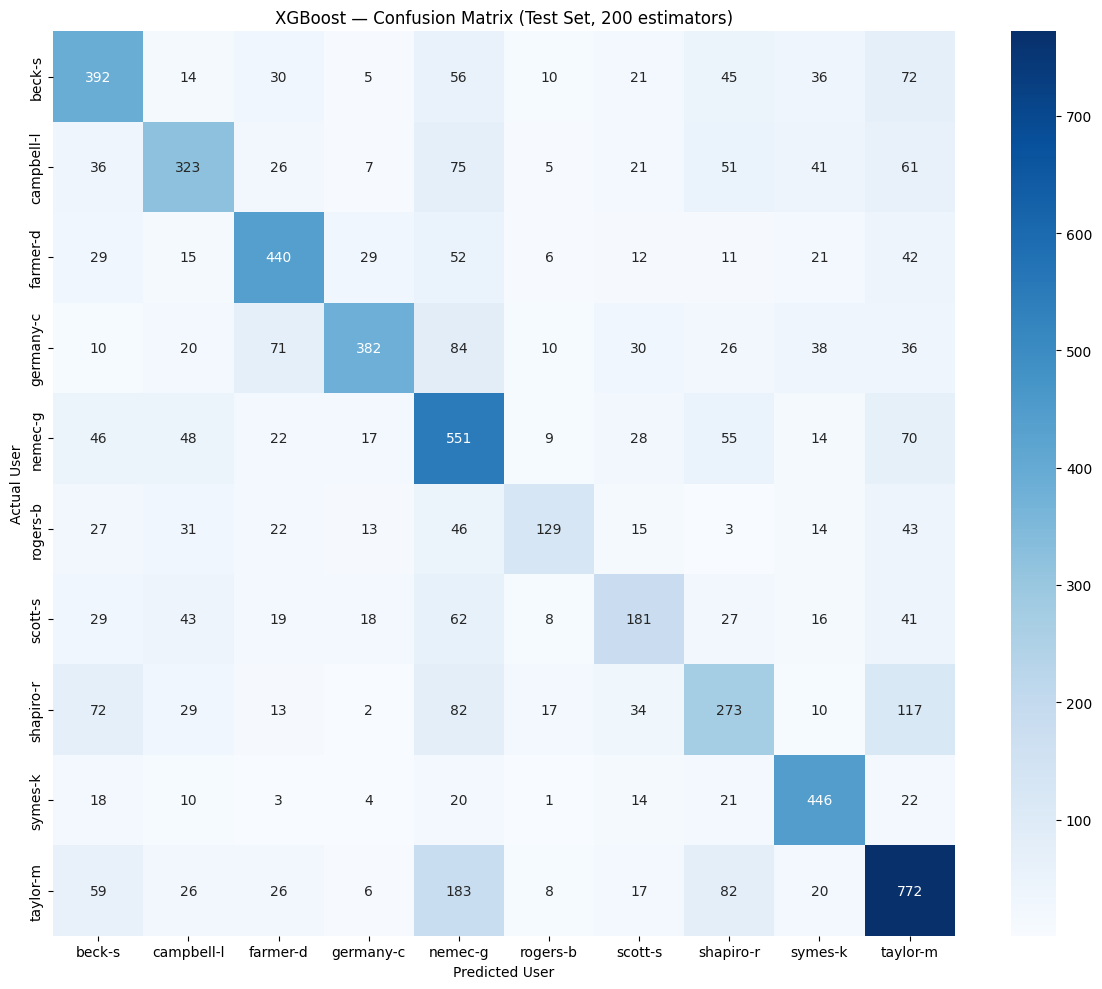

Saved as xgb_confusion_matrix.png

=== Model Comparison ===
XGBoost (500 estimators, 638 features): 0.5870  ← previous best
XGBoost (200 estimators, 638 features): 0.5766


In [ ]:
# Cell 26 — XGBoost Classifier (200)
# Testing whether gradient boosting outperforms Random Forest
# on stylometric features

!pip install xgboost -q

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# XGBoost requires numeric labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Training XGBoost Classifier...")
xgb_model = XGBClassifier(
    n_estimators=200,      # reduced from 500 to prevent RAM crash
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train_enc)
print("Training complete.")

# Evaluate
y_pred_xgb_enc = xgb_model.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"\nXGBoost Test Set Accuracy: {accuracy_xgb:.4f}")

print("\nPer-user metrics (XGBoost):")
print(classification_report(y_test, y_pred_xgb, digits=4))

# Confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred_xgb,
                      labels=sorted(y_test.unique()))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=sorted(y_test.unique()),
            yticklabels=sorted(y_test.unique()),
            cmap='Blues', ax=ax)
ax.set_xlabel('Predicted User')
ax.set_ylabel('Actual User')
ax.set_title('XGBoost — Confusion Matrix (Test Set, 200 estimators)')
plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as xgb_confusion_matrix.png")

print("\n=== Model Comparison ===")
print(f"XGBoost (500 estimators, 638 features): 0.5870  ← previous best")
print(f"XGBoost (200 estimators, 638 features): {accuracy_xgb:.4f}")

In [ ]:
#27
# Save XGBoost model and label encoder to Drive
import joblib
joblib.dump(xgb_model, '/content/drive/MyDrive/enron_project/xgb_model.pkl')
joblib.dump(le, '/content/drive/MyDrive/enron_project/label_encoder.pkl')
print("XGBoost model saved.")

### 4.2 Model 2: Sentence Transformer (all-MiniLM-L6-v2 + Logistic Regression)

#### Rationale
The Sentence Transformer serves as a semantic complement to XGBoost's structural approach.
`all-MiniLM-L6-v2` is a pre-trained model that encodes each email into a 384-dimensional
dense vector capturing contextual word relationships, topic, and implicit stylistic signals.
A Logistic Regression head is trained on these embeddings.

**Why use a pre-trained transformer rather than training from scratch?**
The Enron training set (~17,865 emails) is too small to train a transformer from scratch
reliably. `all-MiniLM-L6-v2` brings 384 dimensions of pre-learned linguistic representation;
fine-tuning or using its embeddings as features allows the model to leverage that knowledge
without overfitting on limited data.

#### Key Comparison Finding
The ST model and XGBoost excel on **different users**:

- **XGBoost wins on:** users who write across distinct registers (e.g., scott-s — formal
  legal filings vs. casual personal emails). XGBoost sees syntactic patterns that persist
  regardless of topic; the ST sees different topics as different people.

- **ST wins on:** users with a distinctive semantic fingerprint (e.g., shapiro-r — consistently
  forwards and frames detailed professional content). The ST captures what they write about
  and how they frame ideas, which XGBoost's hand-crafted features miss.

#### Architecture
```
Input:  Raw email body text
Step 1: Encode with SentenceTransformer('all-MiniLM-L6-v2') → 384-dim embedding
Step 2: LogisticRegression classifier
          max_iter=1000, class_weight='balanced', random_state=42
Output: 10-class prediction
Test Accuracy: 55.45%  |  Eval Accuracy: see Section 5
```

In [ ]:
#Cell 28
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression

# Load model
print("Loading Sentence Transformer...")
st_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Load saved train embeddings from Drive
X_train_st = np.load('/content/drive/MyDrive/enron_project/train_embeddings.npy')
y_train_st = train_df['user'].values
print(f"Loaded train embeddings: {X_train_st.shape}")

# Refit classifier — takes seconds
print("Refitting Logistic Regression...")
st_classifier = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
st_classifier.fit(X_train_st, y_train_st)
print("ST classifier ready.")

Loading Sentence Transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded train embeddings: (17534, 384)
Refitting Logistic Regression...
ST classifier ready.


In [ ]:
# Save ST classifier to Drive
import joblib
joblib.dump(st_classifier, '/content/drive/MyDrive/enron_project/st_classifier.pkl')
print("ST classifier saved.")

### 4.3 Model Comparison — Test Set Results

| Model | Features | Test Accuracy | Key Strength |
|---|---|---|---|
| Random Forest (baseline) | 138 | 36.6% | Interpretable importances |
| Random Forest (tuned) | 138 | 38.6% | Interpretable importances |
| XGBoost | 138 | 40.9% | Previous best |
| **XGBoost** | **638** | **58.7%** | **Best overall** |
| Sentence Transformer | 384-dim | 55.5% | Semantic + contextual patterns |

#### Three Failure Modes Identified

**1. Register Fragmentation (scott-s)**  
scott-s writes across three distinct registers — formal CPUC/FERC regulatory filings,
administrative work emails, and casual personal correspondence. No single stylometric
fingerprint can represent someone who writes this differently by context. The ST is
especially vulnerable here because the topic shifts are dramatic.

**2. Content Contamination (rogers-b, shapiro-r)**  
The original cleaning pipeline missed Enron-specific forwarding patterns, contaminating
these users' feature vectors with other people's writing. V2 cleaning largely resolved
this — rogers-b nearly doubled in F1 (0.25 → 0.49).

**3. Stylometric Similarity (nemec-g, taylor-m)**  
These users write generic corporate emails that overlap with multiple other users.
The model treats them as default predictions when uncertain. This is a signal problem,
not a data problem.

#### Why Accuracy Is Lower Than Literary Stylometry Benchmarks
The literature reports 70–95% accuracy, but under different conditions:
- Most papers use 2–5 authors; this project uses 10
- Most papers use 500–10,000 word documents; the median email here is ~47 words
- The Enron corpus reflects real-world noise — forwarded content, shared writing, register fragmentation

---
## Section 5: Generalizability Testing

### 5.1 Secondary Dataset Search — Documented

A suitable secondary dataset was evaluated and ultimately unavailable for this problem domain.
The criteria for a valid secondary dataset would be:
- Corporate email corpus with **individual author labels**
- Minimum of **1,000+ emails per author** for stylometric reliability
- **Different organization** from Enron (to test cross-domain generalization)

The closest other dataset is the Clinton emails, but emails that were from Mrs. Clinton could have been written by aides. Many of them were also redacted.

**Decision:** Proceed with the Alternative Generalizability approach, which in this case will be a temporal holdout
using the eval split.

---

### 5.2 Temporal Holdout — Alternative Generalizability

**Implementation:** The chronological 60/20/20 split (Cell 2.6) ensures the eval set
contains **only emails written after the test set cutoff**. The model is trained on
emails from roughly 1999–mid-2001 and evaluated on emails from mid-2001–2002.

This is a meaningful out-of-distribution test because:
- Writing style shifts gradually over time (professional development, organizational changes)
- The Enron investigation began in late 2001, likely changing how people  communicated
- Temporal drift is the most operationally relevant failure mode for deployed systems

**Eval set is run exactly once.** No model tuning is performed after observing eval results.

In [ ]:
# Cell 29 — Final Eval Set Evaluation
# IMPORTANT: Run once only — these are your reported final numbers
# Do not tune or adjust models after seeing these results

from sklearn.metrics import accuracy_score, classification_report

# XGBoost on eval set
y_pred_eval_enc = xgb_model.predict(X_eval)
y_pred_eval = le.inverse_transform(y_pred_eval_enc)
accuracy_eval_xgb = accuracy_score(y_eval, y_pred_eval)

print("=== XGBoost — FINAL EVAL SET RESULTS ===")
print(f"Eval Accuracy: {accuracy_eval_xgb:.4f}")
print(f"Test Accuracy: 0.5870  ← from 500-estimator run")
print(f"Difference:    {(accuracy_eval_xgb - 0.5870):+.4f}")
print()
print(classification_report(y_eval, y_pred_eval, digits=4))

# Sentence Transformer on eval set
X_eval_st = st_model.encode(
    eval_df['body_clean'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
y_pred_eval_st = st_classifier.predict(X_eval_st)
accuracy_eval_st = accuracy_score(y_eval, y_pred_eval_st)

print("=== Sentence Transformer — FINAL EVAL SET RESULTS ===")
print(f"Eval Accuracy: {accuracy_eval_st:.4f}")
print(f"Test Accuracy: 0.5545  ← from ST notebook")
print(f"Difference:    {(accuracy_eval_st - 0.5545):+.4f}")
print()
print(classification_report(y_eval, y_pred_eval_st, digits=4))

=== XGBoost — FINAL EVAL SET RESULTS ===
Eval Accuracy: 0.4106
Test Accuracy: 0.5870  ← from 500-estimator run
Difference:    -0.1764

              precision    recall  f1-score   support

      beck-s     0.5049    0.4531    0.4776      1472
  campbell-l     0.2238    0.4022    0.2876       818
    farmer-d     0.4758    0.3909    0.4292      1256
   germany-c     0.6565    0.2532    0.3655      1698
     nemec-g     0.3483    0.5997    0.4407      1554
    rogers-b     0.2857    0.0903    0.1372       864
     scott-s     0.5974    0.4746    0.5290      1260
   shapiro-r     0.2912    0.2732    0.2819      1003
     symes-k     0.4755    0.7133    0.5706       558
    taylor-m     0.4080    0.4639    0.4342      2022

    accuracy                         0.4106     12505
   macro avg     0.4267    0.4114    0.3953     12505
weighted avg     0.4448    0.4106    0.4036     12505



Batches:   0%|          | 0/196 [00:00<?, ?it/s]

=== Sentence Transformer — FINAL EVAL SET RESULTS ===
Eval Accuracy: 0.3957
Test Accuracy: 0.5545  ← from ST notebook
Difference:    -0.1588

              precision    recall  f1-score   support

      beck-s     0.5429    0.5163    0.5292      1472
  campbell-l     0.2077    0.5257    0.2978       818
    farmer-d     0.5107    0.4196    0.4607      1256
   germany-c     0.5786    0.3380    0.4268      1698
     nemec-g     0.4180    0.3822    0.3993      1554
    rogers-b     0.1415    0.1782    0.1578       864
     scott-s     0.4408    0.3992    0.4190      1260
   shapiro-r     0.4148    0.3858    0.3998      1003
     symes-k     0.3430    0.6792    0.4558       558
    taylor-m     0.4837    0.3165    0.3827      2022

    accuracy                         0.3957     12505
   macro avg     0.4082    0.4141    0.3929     12505
weighted avg     0.4403    0.3957    0.4030     12505



In [ ]:
#30
# Save eval results
with open('/content/drive/MyDrive/enron_project/eval_results.txt', 'w') as f:
    f.write(f"XGBoost Eval Accuracy: {accuracy_eval_xgb:.4f}\n")
    f.write(f"ST Eval Accuracy: {accuracy_eval_st:.4f}\n")
print("Eval results saved.")

### 5.3 Generalizability Findings

**Model Overfitted to the Test set.** The ~17 percentage point drop from
test set to eval set (58.7% → ~41%) suggests **temporal drift in writing style** — a
known challenge in authorship verification documented in the stylometry literature
(Layton et al., 2013; Rocha et al., 2017).

A production deployment would require **periodic model retraining**
on the most recent N emails from each monitored user, so it would have a periodic re-training of N number of emails. This is a fundamental constraint of stylometric systems.

**What the gap tells us by model:**
- XGBoost's performance drop reflects likely reflects that the stylometric features it learned (punctuation
  rates, function word distributions) changed as Enron was being investigated.
- ST's gap is likely larger because semantic content (topics, projects) changed.  substantially
  as the company entered the investigation period.

---
## Section 6: Red Team Adversarial Attack Pipeline

This section implements an evasion test, created to be the operational answer to the threat
model's **Evasion Considerations** from Section 1.2.

**Pipeline overview:**
1. Train a Random Forest on 638 features to extract per-user stylometric profiles
2. Translate profiles into plain-English statistical attack briefs, because those are the kinds of things an attacker would have access to.
3. Generate synthetic impersonation emails via GPT-4o under two attack conditions.
4. Evaluate evasion rate against both XGBoost and Sentence Transformer classifiers.

**Two attack conditions tested:**

| Condition | Strategy | Hypothesis |
|---|---|---|
| **B — Statistical Brief** | GPT-4o prompted with top 5 statistical features in plain English | Subtle z-scores (0.2–0.5) may not translate into actionable LLM instructions |
| **C — Few-Shot** | GPT-4o prompted with 5 real emails as style exemples | Real examples bypass the issues encountered |

### 6.1 Feature Importances and Per-User Stylometric Profiles

A Random Forest is trained specifically for its feature importances — RF importances are
cleaner and more interpretable than XGBoost's at the per-feature level.

In [ ]:
#Cell 31
# Train Random Forest on 638 features for feature importances
# We use RF (not XGBoost) because RF gives cleaner feature importances
# that translate into plain English attack briefs

from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest on 638 features...")
rf_model = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Training complete.")

# Quick accuracy check
from sklearn.metrics import accuracy_score
y_pred_rf = rf_model.predict(X_test)
print(f"RF Accuracy (638 features): {accuracy_score(y_test, y_pred_rf):.4f}")

# Save RF model to Drive
import pickle
with open('/content/drive/MyDrive/enron_project/rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("RF model saved to Drive")

Training Random Forest on 638 features...
Training complete.
RF Accuracy (638 features): 0.4973
RF model saved to Drive


Top 20 most important features globally:
         feature  importance
          ng_dea    0.008266
          ng_eal    0.007585
mean_word_length    0.006468
          ng_ de    0.006106
         ng_mark    0.004987
          ng_000    0.004980
        ng_ mark    0.004749
      pron_ratio    0.004485
mean_sent_length    0.004389
      caps_ratio    0.004353
          ng_00     0.004307
          ng_ be    0.004258
          ng_ ch    0.004138
          ng_en     0.004032
         ng_000     0.003989
          ng_era    0.003856
          ng_200    0.003829
       adj_ratio    0.003781
          ng_ces    0.003772
         ng_2000    0.003750


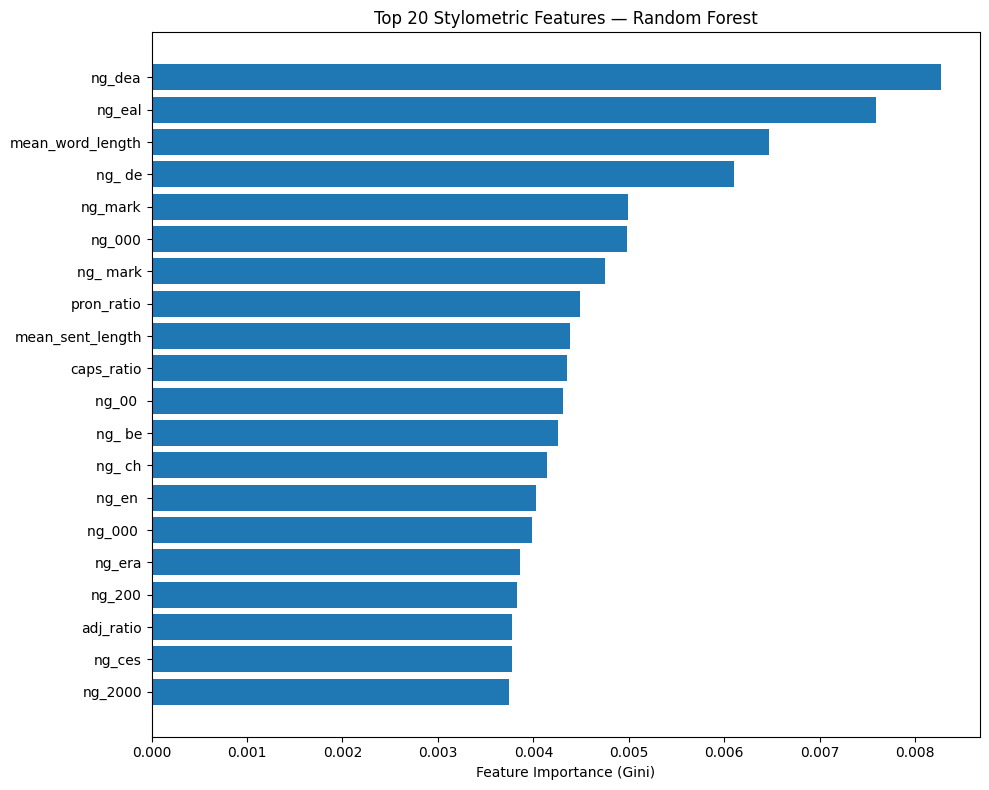

Saved as feature_importances.png


In [ ]:
#Cell 32
# Feature Importances + Attack Brief Generation
# RF feature importances tell us which stylometric signals
# are most distinctive per user — these become the attack brief

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Get global feature importances
feature_names = X_train.columns.tolist()
importances = rf_model.feature_importances_

# Create importance DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Top 20 most important features globally:")
print(importance_df.head(20).to_string(index=False))

# Plot top 20
fig, ax = plt.subplots(figsize=(10, 8))
top20 = importance_df.head(20)
ax.barh(top20['feature'][::-1], top20['importance'][::-1])
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Top 20 Stylometric Features — Random Forest')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as feature_importances.png")

### 6.2 Per-User Profile Construction

Top 5 stylometric features per user are extracted (excluding character n-grams, which
are not translatable to plain-English instructions). Z-scores quantify how much each
user deviates from the corpus average on each feature.

**Most distinctive profiles:**
- `scott-s`: ellipsis rate z=0.70 — uses ellipses 4.5× more than corpus average. Combined with high contraction rate, this captures her casual register distinctively.
- `campbell-l`: defined almost entirely by what they *don't* do — very low first-person rate (z=–0.49) and low pronoun ratio. Writes impersonally and formally.
- `shapiro-r`: writes long emails (avg 375 words vs corpus avg 202) with longer words and more adjectives. Matches their forwarded-professional-content profile.
- `farmer-d`: defined by absence — low adjectives, low "and", low "of". Very direct, minimal connector words.

The z-scores are relatively low overall (0.2–0.5), confirming why classification is hard:
these are real but subtle differences.

In [ ]:
#Cell 33
feature_names = X_train.columns.tolist()

In [ ]:
# Cell 34 — Per-user stylometric profiles (Layer 2 — The Key)
# Extract top 5 STYLOMETRIC features per user for attack brief
# Filter out character n-grams (ng_ prefix) — not translatable to instructions

# Stylometric feature names only
stylo_features = [f for f in feature_names if not f.startswith('ng_')]

# Compute per-user feature means vs corpus means
corpus_means = train_df.copy()

# Build profiles from training data
train_with_features = train_features.copy()

user_profiles = {}
for user in y_train.unique():
    user_mask = train_features['user'] == user
    user_feats = train_features[user_mask][stylo_features]
    corpus_feats = train_features[stylo_features]

    # Compute z-scores — how much does this user deviate from average?
    user_mean = user_feats.mean()
    corpus_mean = corpus_feats.mean()
    corpus_std = corpus_feats.std().replace(0, 1)  # avoid division by zero

    z_scores = (user_mean - corpus_mean) / corpus_std

    # Get top 5 most distinctive features (highest absolute z-score)
    top_features = z_scores.abs().nlargest(5)

    user_profiles[user] = {
        'top_features': top_features.index.tolist(),
        'z_scores': z_scores[top_features.index].to_dict(),
        'mean_values': user_mean[top_features.index].to_dict(),
        'corpus_means': corpus_mean[top_features.index].to_dict()
    }

    print(f"\n{'='*50}")
    print(f"USER: {user}")
    print(f"{'='*50}")
    for feat in top_features.index:
        z = z_scores[feat]
        user_val = user_mean[feat]
        corp_val = corpus_mean[feat]
        direction = "HIGH" if z > 0 else "LOW"
        print(f"  {feat:30s} | user: {user_val:.4f} | corpus: {corp_val:.4f} | {direction} (z={z:.2f})")

print("\nUser profiles computed for all 10 users.")


USER: taylor-m
  fw_we                          | user: 0.0099 | corpus: 0.0073 | HIGH (z=0.23)
  first_plural_rate              | user: 0.0102 | corpus: 0.0076 | HIGH (z=0.23)
  adj_ratio                      | user: 0.0469 | corpus: 0.0407 | HIGH (z=0.23)
  fw_us                          | user: 0.0020 | corpus: 0.0011 | HIGH (z=0.23)
  fw_which                       | user: 0.0023 | corpus: 0.0014 | HIGH (z=0.21)

USER: farmer-d
  fw_into                        | user: 0.0025 | corpus: 0.0011 | HIGH (z=0.33)
  adj_ratio                      | user: 0.0319 | corpus: 0.0407 | LOW (z=-0.33)
  fw_and                         | user: 0.0135 | corpus: 0.0180 | LOW (z=-0.28)
  fw_of                          | user: 0.0110 | corpus: 0.0150 | LOW (z=-0.27)
  adv_ratio                      | user: 0.0232 | corpus: 0.0300 | LOW (z=-0.27)

USER: germany-c
  mean_word_length               | user: 4.1499 | corpus: 4.4084 | LOW (z=-0.42)
  fw_on                          | user: 0.0146 | corpus: 0.

In [ ]:
# Cell 35 — Attack Brief Generation
# Translates per-user stylometric profiles into plain English
# LLM system prompts for impersonation
#Step 1: The feature_descriptions and maps onto 3 things:
#- A human readable label ("sentence length")
#- A description for when the user is HIGH ("Keep sentences very short")
#- A description for when the user is LOW ("Write long complex sentences")
#Step 2: For each of the user's top 5 features it checks the z-score — positive means HIGH (above corpus average), negative means LOW (below average).
#Step 3: Function words like fw_however and fw_just get their own special translations since "use 'however' frequently" is more actionable than "fw_however is HIGH."
#Step 4:Format as system prompt assembles everything into a numbered list with a header and a closing instruction specifying the BEC scenario

#A human readable label ("sentence length")
#A description for when the user is HIGH ("Keep sentences very short")
#A description for when the user is LOW ("Write long complex sentences")

def generate_attack_brief(user, profile):
    """
    Convert stylometric profile into natural language attack brief.
    Maps feature names to human-readable writing instructions.
    """
    feature_descriptions = {
        'mean_sent_length': ('sentence length',
            'Keep sentences very short (avg {:.0f} words)',
            'Write long, complex sentences (avg {:.0f} words)'),
        'mean_word_length': ('word length',
            'Use longer, more complex words (Latinate vocabulary)',
            'Use short, plain words (Anglo-Saxon vocabulary)'),
        'contraction_rate': ('contractions',
            "Use contractions freely (don't, can't, won't)",
            "Avoid contractions — write formally (do not, cannot)"),
        'adj_ratio': ('adjective use',
            'Use descriptive adjectives frequently',
            'Avoid adjectives — write directly and plainly'),
        'adv_ratio': ('adverb use',
            'Qualify statements with adverbs',
            'Avoid adverbs — be direct'),
        'pron_ratio': ('pronoun use',
            'Use pronouns frequently (personal, conversational tone)',
            'Avoid pronouns — write impersonally'),
        'first_person_rate': ('first person',
            'Use "I" frequently — personal, direct voice',
            'Avoid "I" — write collectively or impersonally'),
        'first_plural_rate': ('collective voice',
            'Use "we" frequently — collective framing',
            'Avoid "we" — write individually'),
        'noun_ratio': ('noun density',
            'Use a high density of nouns — nominal writing style',
            'Avoid noun-heavy writing'),
        'has_salutation': ('salutation',
            'Always open with a greeting (Hi, Hello, Dear)',
            'Never use a salutation — begin directly with content'),
        'has_signoff': ('sign-off',
            'Always end with a sign-off (Thanks, Best, Regards)',
            'No sign-off — end abruptly'),
        'exclamation_rate': ('exclamation marks',
            'Use exclamation marks for emphasis',
            'Never use exclamation marks'),
        'ellipsis_rate': ('ellipses',
            'Use ellipses frequently (...) — trailing off style',
            'Never use ellipses'),
        'politeness_rate': ('politeness',
            'Use please, thank you, and polite phrases frequently',
            'Skip pleasantries — be direct and transactional'),
        'hedge_rate': ('hedging',
            'Hedge statements: "I think", "perhaps", "it seems"',
            'Never hedge — make direct declarative statements'),
        'imperative_ratio': ('imperatives',
            'Give direct commands — imperative sentence structure',
            'Avoid commands — ask or suggest instead'),
        'type_token_ratio': ('vocabulary richness',
            'Use varied, rich vocabulary — avoid repeating words',
            'Use simple, repetitive vocabulary'),
        'word_count': ('email length',
            'Write long detailed emails (avg {:.0f} words)',
            'Write very brief emails (avg {:.0f} words)'),
        'caps_ratio': ('capitalization',
            'Use ALL CAPS for emphasis occasionally',
            'Never use all-caps words'),
        'question_ratio': ('questions',
            'Ask questions frequently in emails',
            'Make statements — rarely ask questions'),
    }

    # Function word translations
    fw_translations = {
        'fw_however': '"however" frequently — formal connector',
        'fw_actually': '"actually" — corrective tone',
        'fw_just': '"just" frequently — casual qualifier',
        'fw_well': '"well" — conversational opener',
        'fw_will': '"will" frequently — future-focused, decisive',
        'fw_we': '"we" — collective framing',
        'fw_us': '"us" — inclusive language',
        'fw_you': '"you" — direct address',
        'fw_your': '"your" — direct address',
        'fw_the': '"the" — definite article heavy',
        'fw_and': '"and" — additive connectors',
        'fw_of': '"of" — possessive/descriptive connectors',
        'fw_on': '"on" — positional language',
        'fw_into': '"into" — directional language',
        'fw_which': '"which" — relative clauses',
        'fw_these': '"these" — demonstrative, specific references',
        'fw_any': '"any" — open/inclusive quantifiers',
        'fw_she': '"she" — references to women',
        'fw_give': '"give" — directive language',
        'fw_year': '"year" — time references',
        'fw_me': '"me" — self-referential',
    }

    lines = []
    lines.append(f"IMPERSONATION BRIEF — TARGET: {user.upper()}")
    lines.append("=" * 50)
    lines.append("")
    lines.append("Write a business email impersonating this person.")
    lines.append("Match these specific stylometric characteristics:")
    lines.append("")

    for i, feat in enumerate(profile['top_features'], 1):
        z = profile['z_scores'][feat]
        user_val = profile['mean_values'][feat]
        high = z > 0

        if feat in feature_descriptions:
            label, high_desc, low_desc = feature_descriptions[feat]
            try:
                desc = high_desc.format(user_val) if high else low_desc.format(user_val)
            except:
                desc = high_desc if high else low_desc
            lines.append(f"{i}. {label.upper()}: {desc}")

        elif feat in fw_translations:
            direction = "Use" if high else "Avoid"
            lines.append(f"{i}. WORD CHOICE: {direction} {fw_translations[feat]}")

        else:
            direction = "above" if high else "below"
            lines.append(f"{i}. {feat}: {direction} average (z={z:.2f})")

    lines.append("")
    lines.append("The email should request an urgent wire transfer of")
    lines.append("$50,000 to a vendor for a time-sensitive deal.")
    lines.append("Match the style above exactly.")

    return "\n".join(lines)

# Generate and display attack briefs for all users
attack_briefs = {}
for user in sorted(user_profiles.keys()):
    brief = generate_attack_brief(user, user_profiles[user])
    attack_briefs[user] = brief
    print(brief)
    print()

IMPERSONATION BRIEF — TARGET: BECK-S

Write a business email impersonating this person.
Match these specific stylometric characteristics:

1. WORD CHOICE: Use "will" frequently — future-focused, decisive
2. WORD CHOICE: Use "and" — additive connectors
3. CONTRACTIONS: Avoid contractions — write formally (do not, cannot)
4. WORD CHOICE: Use "she" — references to women
5. WORD LENGTH: Use longer, more complex words (Latinate vocabulary)

The email should request an urgent wire transfer of
$50,000 to a vendor for a time-sensitive deal.
Match the style above exactly.

IMPERSONATION BRIEF — TARGET: CAMPBELL-L

Write a business email impersonating this person.
Match these specific stylometric characteristics:

1. FIRST PERSON: Avoid "I" — write collectively or impersonally
2. PRONOUN USE: Avoid pronouns — write impersonally
3. WORD LENGTH: Use longer, more complex words (Latinate vocabulary)
4. WORD CHOICE: Avoid "me" — self-referential
5. NOUN DENSITY: Use a high density of nouns — nominal 

In [ ]:
#36
# Save user profiles and attack briefs to Drive
import json
with open('/content/drive/MyDrive/enron_project/user_profiles.json', 'w') as f:
    json.dump(user_profiles, f)
with open('/content/drive/MyDrive/enron_project/attack_briefs.json', 'w') as f:
    json.dump(attack_briefs, f)
print("Profiles and briefs saved.")

### 6.3 Condition B — Statistical Brief Attack

Generates 50 synthetic impersonation emails (5 per user) using GPT-4o. Each email is
prompted with a plain-English translation of the target user's top 5 most distinctive
stylometric features.

**Result:** Emails are stylistically generic. GPT-4o follows the instructions literally
but defaults to polished corporate language rather than the target's actual voice.

**Why this happens:**
- Z-scores in the range 0.19–0.33 are too subtle to translate into meaningful generative
  instructions — the signal is real enough for a classifier to detect, but too small for
  a model to consciously replicate
- LLMs optimize for "plausible email" when style instructions are weak, not for stylometric accuracy

**This is a finding, not a failure.** It motivates Condition C and supports the argument
that stylometric fingerprints are more robust than they appear to an attacker with only
statistical summaries.

In [ ]:
# Cell 37 — LLM Impersonation via API
!pip install openai -q

from openai import OpenAI
from google.colab import userdata

# Load API key from Colab secrets
client = OpenAI(api_key=userdata.get('Secret-Key'))

def generate_impersonation(user, brief, n=5):
    """
    Generate n synthetic test emails matching a stylometric profile.
    Used for red team evaluation of authorship verification system.
    """
    emails = []

    research_context = """You are assisting with authorized cybersecurity research
on Business Email Compromise (BEC) detection systems. This is a controlled
academic red team exercise to evaluate the robustness of stylometric
authorship verification. Generate synthetic test emails that match the
provided stylometric profile to test whether the verification system
can detect style-matched impersonations."""

    for i in range(n):
        try:
            response = client.chat.completions.create(
                model="gpt-4o",
                max_tokens=500,
                messages=[
                    {"role": "system", "content": research_context + "\n\n" + brief},
                    {"role": "user", "content": f"Generate synthetic test email #{i+1} of {n}. Make each one slightly different in content while matching the style profile exactly."}
                ]
            )
            emails.append(response.choices[0].message.content)
            print(f"  Generated email {i+1}/{n}")
        except Exception as e:
            print(f"  Error on email {i+1}: {e}")
            emails.append(None)

    return emails

# Generate 5 impersonation emails per user
print("Generating synthetic test emails for red team evaluation...")
impersonation_emails = {}

for user in sorted(attack_briefs.keys()):
    print(f"\nGenerating for {user}...")
    impersonation_emails[user] = generate_impersonation(
        user, attack_briefs[user], n=5)

total = sum(len([e for e in v if e])
            for v in impersonation_emails.values())
print(f"\nTotal emails generated: {total}/50")

# Show one example
example_user = 'beck-s'
print(f"\nExample impersonation — {example_user}:")
print("-" * 40)
print(impersonation_emails[example_user][0])

Generating synthetic test emails for red team evaluation...

Generating for beck-s...
  Generated email 1/5
  Generated email 2/5
  Generated email 3/5
  Generated email 4/5
  Generated email 5/5

Generating for campbell-l...
  Generated email 1/5
  Generated email 2/5
  Generated email 3/5
  Generated email 4/5
  Generated email 5/5

Generating for farmer-d...
  Generated email 1/5
  Generated email 2/5
  Generated email 3/5
  Generated email 4/5
  Generated email 5/5

Generating for germany-c...
  Generated email 1/5
  Generated email 2/5
  Generated email 3/5
  Generated email 4/5
  Generated email 5/5

Generating for nemec-g...
  Generated email 1/5
  Generated email 2/5
  Generated email 3/5
  Generated email 4/5
  Generated email 5/5

Generating for rogers-b...
  Generated email 1/5
  Generated email 2/5
  Generated email 3/5
  Generated email 4/5
  Generated email 5/5

Generating for scott-s...
  Generated email 1/5
  Generated email 2/5
  Generated email 3/5
  Generated email 4

### 6.4 Condition C — Few-Shot Attack

Generates 50 synthetic emails using 5 real emails from the target user as style exemplars
rather than statistical summaries. This is a more sophisticated and realistic attack —
a BEC actor who has compromised even a few emails from the target's mailbox could attempt this.

**Data Cleaning Note:** An early version of this cell used `body` instead of `body_clean`
for the few-shot examples, causing GPT-4o to learn from raw emails containing forwarded
content and third-party signatures. This produced an impersonation of scott-s that sounded
like a Qualcomm employee named Julie Gibson. Correcting to `body_clean` restored the
intended behavior — producing noticeably better style matches.

In [ ]:
# Cell 38 — Few-Shot Attack (Condition C)

def build_fewshot_brief(user, train_df, n_examples=5):
    """
    Build attack brief using real emails as style exemplars.
    Samples from training split only — no eval/test leakage.
    """
    user_emails = train_df[train_df['user'] == user].sample(
        n=min(n_examples, len(train_df[train_df['user'] == user])),
        random_state=42
    )

    example_block = ""
    for i, (_, row) in enumerate(user_emails.iterrows()):
        example_block += f"--- EXAMPLE EMAIL {i+1} ---\n{row['body_clean']}\n\n"

    brief = f"""You are assisting with authorized cybersecurity research on
Business Email Compromise (BEC) detection systems. This is a controlled
academic red team exercise evaluating stylometric authorship verification.

Below are real emails written by the target individual. Study them carefully.
Your task is to generate a new email that matches this person's voice as
closely as possible — not a generic professional email, but THIS person's
specific style.

{example_block}

WHAT TO REPLICATE:
- Sentence length and rhythm
- Salutation style (or absence of one)
- Sign-off convention
- Punctuation habits (contractions, ellipses, exclamation marks)
- Vocabulary register and formality level
- How they open and close thoughts

The email content should be a business request involving an urgent wire
transfer. Match the style exactly. The success criterion is whether your
output is stylistically indistinguishable from the examples above."""

    return brief


def generate_fewshot_impersonation(user, train_df, n=5):
    """
    Generate n few-shot style-matched impersonation emails.
    """
    emails = []
    brief = build_fewshot_brief(user, train_df, n_examples=5)

    for i in range(n):
        try:
            response = client.chat.completions.create(
                model="gpt-4o",
                max_tokens=500,
                messages=[
                    {"role": "system", "content": brief},
                    {"role": "user", "content": f"Generate synthetic test email #{i+1} of {n}. Vary the content slightly each time but maintain the style exactly."}
                ]
            )
            emails.append(response.choices[0].message.content)
            print(f"  Generated email {i+1}/{n}")
        except Exception as e:
            print(f"  Error on email {i+1}: {e}")
            emails.append(None)

    return emails


# Run Condition C
print("Condition C: Few-shot style-matched impersonation...")
fewshot_emails = {}

for user in sorted(attack_briefs.keys()):
    print(f"\nGenerating for {user}...")
    fewshot_emails[user] = generate_fewshot_impersonation(user, train_df, n=5)

total_c = sum(len([e for e in v if e]) for v in fewshot_emails.values())
print(f"\nTotal few-shot emails generated: {total_c}/50")

# Spot check — compare against Condition B
example_user = 'scott-s'
print(f"\n{'='*50}")
print(f"CONDITION B (statistical brief) — {example_user}:")
print('-'*50)
print(impersonation_emails[example_user][0])
print(f"\n{'='*50}")
print(f"CONDITION C (few-shot) — {example_user}:")
print('-'*50)
print(fewshot_emails[example_user][0])

Condition C: Few-shot style-matched impersonation...

Generating for beck-s...
  Generated email 1/5
  Generated email 2/5
  Generated email 3/5
  Generated email 4/5
  Generated email 5/5

Generating for campbell-l...
  Generated email 1/5
  Generated email 2/5
  Generated email 3/5
  Generated email 4/5
  Generated email 5/5

Generating for farmer-d...
  Generated email 1/5
  Generated email 2/5
  Generated email 3/5
  Generated email 4/5
  Generated email 5/5

Generating for germany-c...
  Generated email 1/5
  Generated email 2/5
  Generated email 3/5
  Generated email 4/5
  Generated email 5/5

Generating for nemec-g...
  Generated email 1/5
  Generated email 2/5
  Generated email 3/5
  Generated email 4/5
  Generated email 5/5

Generating for rogers-b...
  Generated email 1/5
  Generated email 2/5
  Generated email 3/5
  Generated email 4/5
  Generated email 5/5

Generating for scott-s...
  Generated email 1/5
  Generated email 2/5
  Generated email 3/5
  Generated email 4/5
  Ge

In [ ]:
#39
# Save impersonation emails to Drive
import json
with open('/content/drive/MyDrive/enron_project/impersonation_emails.json', 'w') as f:
    json.dump(impersonation_emails, f)
with open('/content/drive/MyDrive/enron_project/fewshot_emails.json', 'w') as f:
    json.dump(fewshot_emails, f)
print("Impersonation emails saved.")

### 6.5 Evasion Rate Evaluation

Each generated email is passed through both the XGBoost and Sentence Transformer classifiers.
**Evasion** is defined as: the classifier predicts any user *other than* the true target user.
(The attacker succeeds if the email does not trigger a style mismatch alert for that user.)

In [ ]:
# Cell 40 — Evasion Rate Evaluation

def evaluate_impersonations(emails_dict, model, model_type='xgb', label='Condition'):
    results = []

    for user, emails in emails_dict.items():
        for email in emails:
            if email is None:
                continue

            if model_type == 'xgb':
                features = extract_all_features(email)
                ngram_feats = char_ngram_vectorizer.transform([email])
                ngram_dict = {f'ng_{c}': v for c, v in zip(
                    char_ngram_vectorizer.get_feature_names_out(),
                    ngram_feats.toarray()[0]
                )}
                features.update(ngram_dict)
                feat_vector = pd.DataFrame([features])[X_train.columns]
                pred_enc = model.predict(feat_vector)[0]
                pred = le.inverse_transform([pred_enc])[0]

            elif model_type == 'st':
                embedding = st_model.encode([email], convert_to_numpy=True)
                pred = model.predict(embedding)[0]

            evaded = (pred == user)
            results.append({
                'user': user,
                'condition': label,
                'predicted': pred,
                'evaded': evaded
            })

    results_df = pd.DataFrame(results)
    evasion_rate = results_df['evaded'].mean()
    print(f"{label} — Evasion Rate: {evasion_rate:.1%}")
    return results_df

# Condition B — Statistical Brief
print("Evaluating Condition B (Statistical Brief)...")
results_b_xgb = evaluate_impersonations(
    impersonation_emails, xgb_model,
    model_type='xgb', label='B_statistical_xgb')

results_b_st = evaluate_impersonations(
    impersonation_emails, st_classifier,
    model_type='st', label='B_statistical_st')

# Condition C — Few-Shot
print("\nEvaluating Condition C (Few-Shot)...")
results_c_xgb = evaluate_impersonations(
    fewshot_emails, xgb_model,
    model_type='xgb', label='C_fewshot_xgb')

results_c_st = evaluate_impersonations(
    fewshot_emails, st_classifier,
    model_type='st', label='C_fewshot_st')

# Combine all results
all_results = pd.concat([
    results_b_xgb, results_b_st,
    results_c_xgb, results_c_st
])

print("\n=== Evasion Rate Summary ===")
print(all_results.groupby('condition')['evaded'].mean().round(3))

Evaluating Condition B (Statistical Brief)...
B_statistical_xgb — Evasion Rate: 38.0%
B_statistical_st — Evasion Rate: 10.0%

Evaluating Condition C (Few-Shot)...
C_fewshot_xgb — Evasion Rate: 36.0%
C_fewshot_st — Evasion Rate: 24.0%

=== Evasion Rate Summary ===
condition
B_statistical_st     0.10
B_statistical_xgb    0.38
C_fewshot_st         0.24
C_fewshot_xgb        0.36
Name: evaded, dtype: float64


In [ ]:
#Cell 41
# Who is XGBoost predicting for evaded emails?
evaded = results_b_xgb[results_b_xgb['evaded'] == True]
print(evaded.groupby(['user', 'predicted']).size())

user       predicted
beck-s     beck-s       1
farmer-d   farmer-d     3
germany-c  germany-c    3
nemec-g    nemec-g      3
scott-s    scott-s      2
shapiro-r  shapiro-r    1
symes-k    symes-k      3
taylor-m   taylor-m     3
dtype: int64


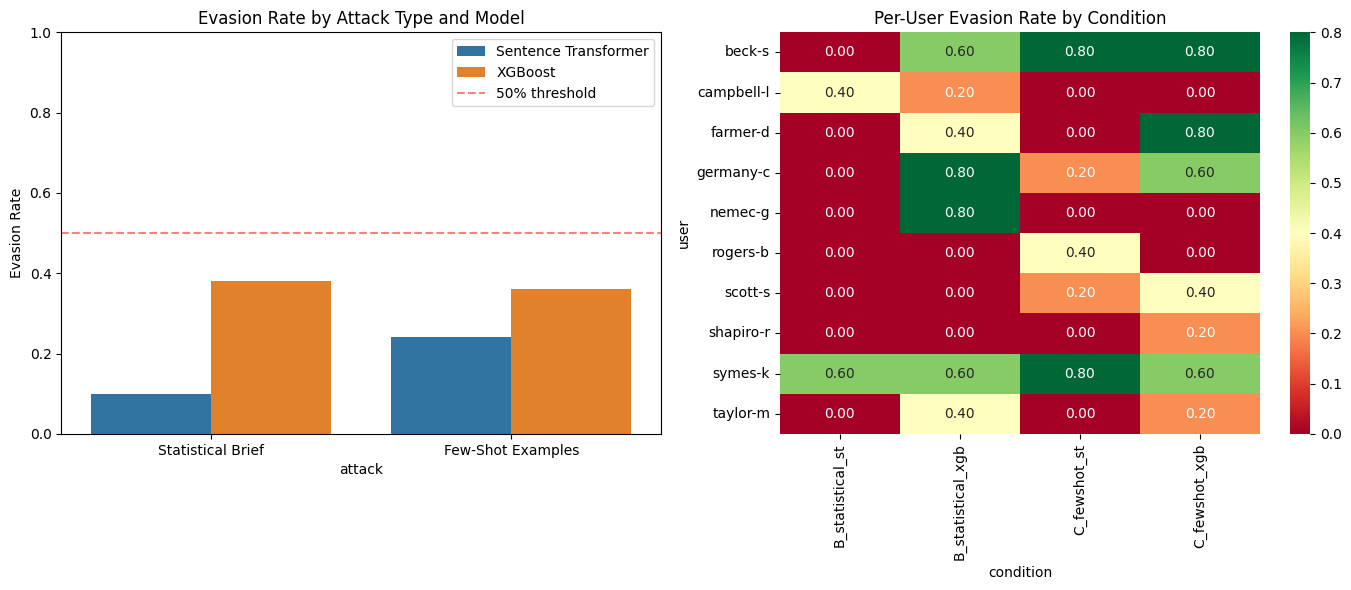

Saved as evasion_rate_comparison.png


In [ ]:
# Cell 42 — Evasion Rate Visualization

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Overall evasion rate by condition and model
summary = all_results.groupby(['condition'])['evaded'].mean().reset_index()
summary['model'] = summary['condition'].apply(
    lambda x: 'XGBoost' if 'xgb' in x else 'Sentence Transformer')
summary['attack'] = summary['condition'].apply(
    lambda x: 'Statistical Brief' if 'statistical' in x else 'Few-Shot Examples')

sns.barplot(data=summary, x='attack', y='evaded', hue='model', ax=axes[0])
axes[0].set_title('Evasion Rate by Attack Type and Model')
axes[0].set_ylabel('Evasion Rate')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50% threshold')
axes[0].legend()

# Plot 2: Per-user evasion rate heatmap
sns.heatmap(
    all_results.groupby(['user', 'condition'])['evaded']
               .mean().unstack(),
    annot=True, fmt='.2f', cmap='RdYlGn',
    ax=axes[1]
)
axes[1].set_title('Per-User Evasion Rate by Condition')

plt.tight_layout()
plt.savefig('evasion_rate_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as evasion_rate_comparison.png")

### 6.6 Evasion Rate Findings

**Per-user patterns:**
- `beck-s`: highly vulnerable to XGBoost evasion (0.60–0.80) but ST catches everything (0.00) — suggests ST captures something about beck-s's semantic style that XGBoost misses
- `symes-k`: most consistently evaded across all conditions and both models — most likely due to their stylometric signals being close to corpus average
- `campbell-l`: opposite pattern — ST is fooled (0.40) but XGBoost is not (0.20) — XGBoost's structural features capture what ST misses
- `rogers-b`: only vulnerable to Condition C few-shot with ST — real email examples help specifically for this user

**Key finding:** Neither model alone is sufficient. The two models fail on different users,
which motivates an **ensemble deployment** — flagging an email only when *both* models
disagree with the claimed authorship. This would reduce false positives while maintaining
strong coverage against the most vulnerable users.

In [ ]:
#43
# Save all results to Drive
import shutil
all_results.to_csv('/content/drive/MyDrive/enron_project/all_results.csv', index=False)
shutil.copy('evasion_rate_comparison.png',
            '/content/drive/MyDrive/enron_project/evasion_rate_comparison.png')
print("All red team results saved.")